<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4142/612045529.py:113: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Partial Rank Correlation Coefficients (PRCC) terhadap $\mathcal{R}_0$", fontsize=14, fontweight='bold')


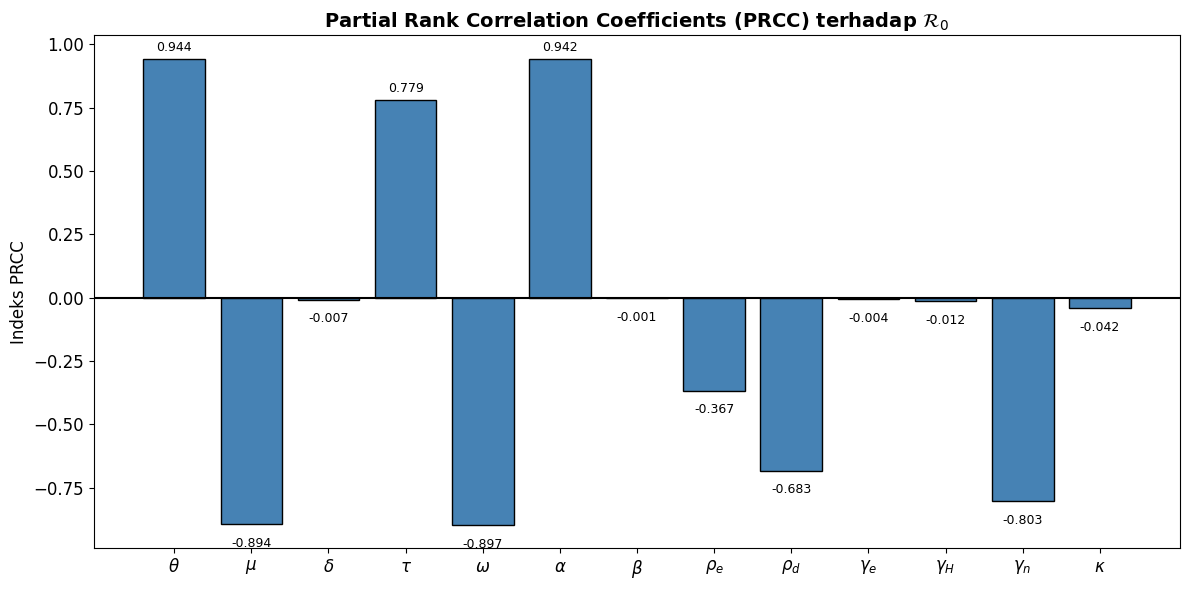


Hasil Indeks PRCC (Diurutkan berdasarkan pengaruh terhadap R0):
   Parameter      PRCC
0      theta  0.943775
1      alpha  0.942352
2        tau  0.779218
3       beta -0.000518
4    gamma_e -0.004371
5      delta -0.007052
6    gamma_H -0.012216
7      kappa -0.042344
8      rho_e -0.367196
9      rho_d -0.683025
10   gamma_n -0.803145
11        mu -0.894409
12     omega -0.896897


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.linear_model import LinearRegression
import pandas as pd

# ==================================================
# 1) Nilai nominal parameter Campak (base case)
# ==================================================
params_base = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# ==================================================
# 2) Aturan bounds (Rentang variasi parameter)
# ==================================================
# Secara default, kita asumsikan setiap parameter bervariasi +/- 20%
pct_default = 0.20

def build_bounds(params, pct):
    bounds = {}
    for name, v in params.items():
        low = max(v * (1 - pct), 1e-12) # Menghindari nilai nol atau negatif
        high = v * (1 + pct)
        bounds[name] = [low, high]
    return bounds

bounds = build_bounds(params_base, pct_default)

param_order = list(params_base.keys())
bounds_list = [bounds[name] for name in param_order]

# ==================================================
# 3) Sampling parameter (Monte Carlo)
# ==================================================
N = 2000
np.random.seed(42)
X = np.array([np.random.uniform(low, high, N) for (low, high) in bounds_list]).T

# ==================================================
# 4) Definisi R0 sesuai model Campak
# ==================================================
def calculate_R0(params):
    # Unpack array sesuai dengan urutan param_order
    (theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa) = params

    # Variabel Perantara
    m1 = mu + beta
    m2 = mu + tau
    m3 = mu + delta + rho_e + rho_d + gamma_n
    m4 = mu + omega + tau

    # Rumus R0
    num = alpha * theta * beta * m2
    den = mu * m1 * m3 * m4

    return num / den

Y = np.array([calculate_R0(row) for row in X])

# ==================================================
# 5) Hitung PRCC
# ==================================================
X_rank = np.array([rankdata(X[:,j]) for j in range(X.shape[1])]).T
Y_rank = rankdata(Y)

prccs = []
for i in range(X_rank.shape[1]):
    others = np.delete(np.arange(X_rank.shape[1]), i)

    # Residual Xi
    reg_X = LinearRegression().fit(X_rank[:, others], X_rank[:, i])
    R_Xi = X_rank[:, i] - reg_X.predict(X_rank[:, others])
    R_Xi = (R_Xi - np.mean(R_Xi)) / np.std(R_Xi)

    # Residual Y
    reg_Y = LinearRegression().fit(X_rank[:, others], Y_rank)
    R_Y = Y_rank - reg_Y.predict(X_rank[:, others])
    R_Y = (R_Y - np.mean(R_Y)) / np.std(R_Y)

    # Korelasi Pearson antara residual
    prcc = np.corrcoef(R_Xi, R_Y)[0,1]
    prccs.append(prcc)

# ==================================================
# 6) Plot hasil PRCC
# ==================================================
# Label dengan format LaTeX untuk plot
param_labels = [
    r'$\theta$', r'$\mu$', r'$\delta$', r'$\tau$', r'$\omega$',
    r'$\alpha$', r'$\beta$', r'$\rho_e$', r'$\rho_d$', r'$\gamma_e$',
    r'$\gamma_H$', r'$\gamma_n$', r'$\kappa$'
]

plt.figure(figsize=(12,6))
bars = plt.bar(range(len(param_order)), prccs, tick_label=param_labels,
               color="steelblue", edgecolor="black")
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Indeks PRCC", fontsize=12)
plt.title("Partial Rank Correlation Coefficients (PRCC) terhadap $\mathcal{R}_0$", fontsize=14, fontweight='bold')
plt.axhline(0, color="black", linewidth=1.5)

# Menambahkan nilai PRCC di atas/bawah batang grafik
for bar in bars:
    yval = bar.get_height()
    if yval != 0: # Hanya tampilkan jika bukan 0
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.02 if yval > 0 else -0.05),
                 round(yval, 3), ha='center', va='bottom' if yval > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

# ==================================================
# 7) Simpan hasil PRCC ke DataFrame
# ==================================================
prcc_df = pd.DataFrame({"Parameter": param_order, "PRCC": prccs})
print("\nHasil Indeks PRCC (Diurutkan berdasarkan pengaruh terhadap R0):")
print(prcc_df.sort_values(by="PRCC", ascending=False).reset_index(drop=True))

In [ ]:
# Analisis Sensitivitas Per Parameter
import sympy as sp

# Mendefinisikan parameter sebagai simbol matematika
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial terhadap setiap parameter
partials = {
    'alpha': sp.diff(R0, alpha),
    'beta': sp.diff(R0, beta),
    'theta': sp.diff(R0, theta),
    'mu': sp.diff(R0, mu),
    'tau': sp.diff(R0, tau),
    'omega': sp.diff(R0, omega),
    'delta': sp.diff(R0, delta),
    'rho_e': sp.diff(R0, rho_e),
    'rho_d': sp.diff(R0, rho_d),
    'gamma_n': sp.diff(R0, gamma_n),
}

# Menghitung indeks sensitivitas ternormalisasi
sensitivities = {}
for param, partial in partials.items():
    sensitivities[param] = partial * sp.symbols(param) / R0

# Mencetak hasil sensitivitas yang sudah disederhanakan
for param, sensitivity in sensitivities.items():
    print(f"Sensitivity of {param}:")
    print(sp.simplify(sensitivity))
    print()

Sensitivity of alpha:
1

Sensitivity of beta:
mu/(beta + mu)

Sensitivity of theta:
1

Sensitivity of mu:
(-mu*(beta + mu)*(mu + tau)*(mu + omega + tau) - mu*(beta + mu)*(mu + tau)*(delta + gamma_n + mu + rho_d + rho_e) + mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e) - mu*(mu + tau)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e) - (beta + mu)*(mu + tau)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))/((beta + mu)*(mu + tau)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))

Sensitivity of tau:
omega*tau/((mu + tau)*(mu + omega + tau))

Sensitivity of omega:
-omega/(mu + omega + tau)

Sensitivity of delta:
-delta/(delta + gamma_n + mu + rho_d + rho_e)

Sensitivity of rho_e:
-rho_e/(delta + gamma_n + mu + rho_d + rho_e)

Sensitivity of rho_d:
-rho_d/(delta + gamma_n + mu + rho_d + rho_e)

Sensitivity of gamma_n:
-gamma_n/(delta + gamma_n + mu + rho_d + rho_e)



In [ ]:
# Analisis Sensitivitas Spesifik terhadap Parameter Alpha
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap alpha
dR0_dalpha = sp.diff(R0, alpha)

# Menghitung sensitivitas ternormalisasi terhadap alpha
sensitivity_alpha = alpha / R0 * dR0_dalpha

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_alpha_substituted = sensitivity_alpha.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap alpha:")
print(sp.simplify(dR0_dalpha))
print()
print("Nilai Sensitivitas Normalisasi terhadap alpha:")
print(sp.simplify(sensitivity_alpha_substituted))


Turunan parsial R0 terhadap alpha:
beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))

Nilai Sensitivitas Normalisasi terhadap alpha:
1


In [ ]:
# Analisis Sensitivitas Spesifik terhadap Parameter Beta
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap beta
dR0_dbeta = sp.diff(R0, beta)

# Menghitung sensitivitas ternormalisasi terhadap beta
sensitivity_beta = (beta / R0) * dR0_dbeta

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_beta_substituted = sensitivity_beta.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap beta:")
print(sp.simplify(dR0_dbeta))
print()
print("Nilai Sensitivitas Normalisasi terhadap beta:")
print(sp.simplify(sensitivity_beta_substituted))


Turunan parsial R0 terhadap beta:
alpha*theta*(mu + tau)/((beta + mu)**2*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))

Nilai Sensitivitas Normalisasi terhadap beta:
0.000369863150634333


In [ ]:
# Analisis sensitivitas terhadap theta
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap theta
dR0_dtheta = sp.diff(R0, theta)

# Menghitung sensitivitas ternormalisasi terhadap theta
sensitivity_theta = (theta / R0) * dR0_dtheta

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_theta_substituted = sensitivity_theta.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap theta:")
print(sp.simplify(dR0_dtheta))
print()
print("Nilai Sensitivitas Normalisasi terhadap theta:")
print(sp.simplify(sensitivity_theta_substituted))


Turunan parsial R0 terhadap theta:
alpha*beta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))

Nilai Sensitivitas Normalisasi terhadap theta:
1


In [ ]:
# Analisis sensitivitas terhadap mu
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap mu
dR0_dmu = sp.diff(R0, mu)

# Menghitung sensitivitas ternormalisasi terhadap mu
sensitivity_mu = (mu / R0) * dR0_dmu

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_mu_substituted = sensitivity_mu.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap mu:")
print(sp.simplify(dR0_dmu))
print()
print("Nilai Sensitivitas Normalisasi terhadap mu:")
print(sp.simplify(sensitivity_mu_substituted))


Turunan parsial R0 terhadap mu:
alpha*beta*theta*(-mu*(beta + mu)*(mu + tau)*(mu + omega + tau) - mu*(beta + mu)*(mu + tau)*(delta + gamma_n + mu + rho_d + rho_e) + mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e) - mu*(mu + tau)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e) - (beta + mu)*(mu + tau)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e))/(mu**2*(beta + mu)**2*(mu + omega + tau)**2*(delta + gamma_n + mu + rho_d + rho_e)**2)

Nilai Sensitivitas Normalisasi terhadap mu:
-0.723131648811855


In [ ]:
# Analisis sensitivitas terhadap tau
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap tau
dR0_dtau = sp.diff(R0, tau)

# Menghitung sensitivitas ternormalisasi terhadap tau
sensitivity_tau = (tau / R0) * dR0_dtau

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_tau_substituted = sensitivity_tau.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap tau:")
print(sp.simplify(dR0_dtau))
print()
print("Nilai Sensitivitas Normalisasi terhadap tau:")
print(sp.simplify(sensitivity_tau_substituted))


Turunan parsial R0 terhadap tau:
alpha*beta*omega*theta/(mu*(beta + mu)*(mu + omega + tau)**2*(delta + gamma_n + mu + rho_d + rho_e))

Nilai Sensitivitas Normalisasi terhadap tau:
0.472500000000000


In [ ]:
# Analisis sensitivitas terhadap omega
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap omega
dR0_domega = sp.diff(R0, omega)

# Menghitung sensitivitas ternormalisasi terhadap omega
sensitivity_omega = (omega / R0) * dR0_domega

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_omega_substituted = sensitivity_omega.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap omega:")
print(sp.simplify(dR0_domega))
print()
print("Nilai Sensitivitas Normalisasi terhadap omega:")
print(sp.simplify(sensitivity_omega_substituted))


Turunan parsial R0 terhadap omega:
-alpha*beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)**2*(delta + gamma_n + mu + rho_d + rho_e))

Nilai Sensitivitas Normalisasi terhadap omega:
-0.750000000000000


In [ ]:
# Analisis sensitivitas terhadap delta
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menghitung turunan parsial R0 terhadap delta
dR0_ddelta = sp.diff(R0, delta)

# Menghitung sensitivitas ternormalisasi terhadap delta
sensitivity_delta = (delta / R0) * dR0_ddelta

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_delta_substituted = sensitivity_delta.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap delta:")
print(sp.simplify(dR0_ddelta))
print()
print("Nilai Sensitivitas Normalisasi terhadap delta:")
print(sp.simplify(sensitivity_delta_substituted))


Turunan parsial R0 terhadap delta:
-alpha*beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e)**2)

Nilai Sensitivitas Normalisasi terhadap delta:
-0.00212258644233286


In [ ]:
# Analisis sensitivitas terhadap rho_e
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# # Menghitung turunan parsial R0 terhadap rho_e
dR0_drho_e = sp.diff(R0, rho_e)

# Menghitung sensitivitas ternormalisasi terhadap rho_e
sensitivity_rho_e = (rho_e / R0) * dR0_drho_e

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_rho_e_substituted = sensitivity_rho_e.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap rho_e:")
print(sp.simplify(dR0_drho_e))
print()
print("Nilai Sensitivitas Normalisasi terhadap rho_e:")
print(sp.simplify(sensitivity_rho_e_substituted))


Turunan parsial R0 terhadap rho_e:
-alpha*beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e)**2)

Nilai Sensitivitas Normalisasi terhadap rho_e:
-0.141505762822191


In [ ]:
# Analisis sensitivitas terhadap rho_d
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# # Menghitung turunan parsial R0 terhadap rho_d
dR0_drho_d = sp.diff(R0, rho_d)

# Menghitung sensitivitas ternormalisasi terhadap rho_d
sensitivity_rho_d = (rho_d / R0) * dR0_drho_d

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_rho_d_substituted = sensitivity_rho_d.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap rho_d:")
print(sp.simplify(dR0_drho_d))
print()
print("Nilai Sensitivitas Normalisasi terhadap rho_d:")
print(sp.simplify(sensitivity_rho_d_substituted))


Turunan parsial R0 terhadap rho_d:
-alpha*beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e)**2)

Nilai Sensitivitas Normalisasi terhadap rho_d:
-0.353764407055477


In [ ]:
# Analisis sensitivitas terhadap gamma_n
import sympy as sp

# Mendefinisikan simbol parameter
theta, mu, delta, tau, omega, alpha, beta, rho_e, rho_d, gamma_e, gamma_H, gamma_n, kappa = sp.symbols('theta mu delta tau omega alpha beta rho_e rho_d gamma_e gamma_H gamma_n kappa')

# Mendefinisikan nilai numerik parameter
params_values = {
    "theta": 0.000045,
    "mu": 0.000037,
    "delta": 0.0003,
    "tau": 0.000063,
    "omega": 0.0003,
    "alpha": 0.6,
    "beta": 0.1,
    "rho_e": 0.02,
    "rho_d": 0.05,
    "gamma_e": 0.142,
    "gamma_H": 0.142,
    "gamma_n": 0.071,
    "kappa": 0.150
}

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# # Menghitung turunan parsial R0 terhadap gamma_n
dR0_dgamma_n = sp.diff(R0, gamma_n)

# Menghitung sensitivitas ternormalisasi terhadap gamma_n
sensitivity_gamma_n = (gamma_n / R0) * dR0_dgamma_n

# Substitusi nilai parameter numerik ke dalam rumus sensitivitas
sensitivity_gamma_n_substituted = sensitivity_gamma_n.subs(params_values)

# Menampilkan hasil
print("Turunan parsial R0 terhadap gamma_n:")
print(sp.simplify(dR0_dgamma_n))
print()
print("Nilai Sensitivitas Normalisasi terhadap gamma_n:")
print(sp.simplify(sensitivity_gamma_n_substituted))


Turunan parsial R0 terhadap gamma_n:
-alpha*beta*theta*(mu + tau)/(mu*(beta + mu)*(mu + omega + tau)*(delta + gamma_n + mu + rho_d + rho_e)**2)

Nilai Sensitivitas Normalisasi terhadap gamma_n:
-0.502345458018778


=== HASIL PERHITUNGAN NUMERIK ===
1. Persamaan Garis      : R0 = 2.1505 * alpha
2. Titik Kritis (R0=1)  : alpha = 0.46501


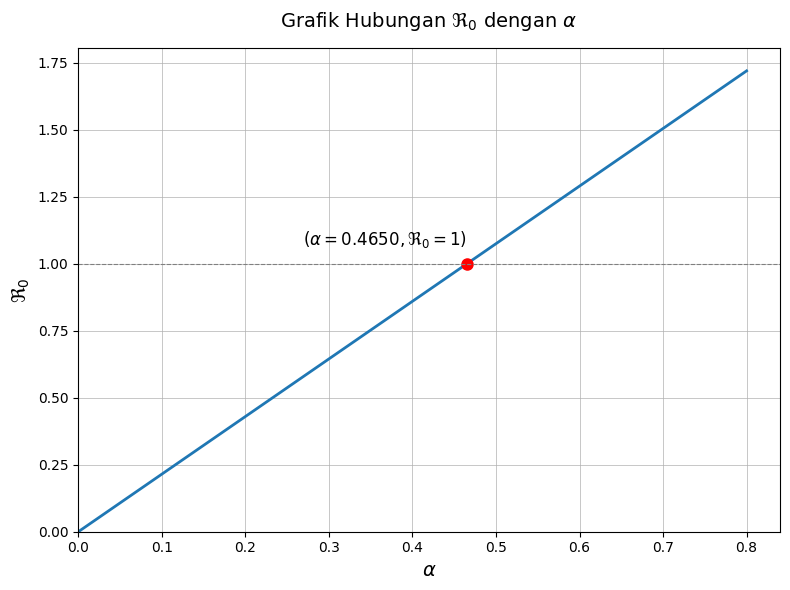

In [ ]:
# Grafik R0 terhadap Alpha
import matplotlib.pyplot as plt
import numpy as np

# Nilai numerik parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.6
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Menghitung nilai gradien
gradien_C = (theta * beta * m2) / (mu * m1 * m3 * m4)

# Titik kritis (saat R0 = 1)
alpha_kritis = 1 / gradien_C

# Menampilkan nilai perhitungan sebagai output
print("=== HASIL PERHITUNGAN NUMERIK ===")
print(f"1. Persamaan Garis      : R0 = {gradien_C:.4f} * alpha")
print(f"2. Titik Kritis (R0=1)  : alpha = {alpha_kritis:.5f}")
print("===================================")

# Membuat grafik
alpha_values = np.linspace(0, 0.8, 100)
r0_values = gradien_C * alpha_values
plt.figure(figsize=(8, 6))

# Plot garis biru
plt.plot(alpha_values, r0_values, label=r'$\Re_0$', color='#1f77b4', linewidth=2)

# Plot titik merah (Titik Kritis)
plt.plot(alpha_kritis, 1, 'ro', markersize=8)

# Label pada titik merah
label_text = fr'$(\alpha = {alpha_kritis:.4f}, \Re_0 = 1)$'
plt.text(alpha_kritis, 1.05, label_text, fontsize=12, ha='right', va='bottom', color='black')

# Grafik
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xlabel(r'$\alpha$', fontsize=14)
plt.ylabel(r'$\Re_0$', fontsize=14)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(left=0)
plt.ylim(bottom=0)

# Judul gambar
plt.title(r'Grafik Hubungan $\Re_0$ dengan $\alpha$', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('grafik_final_measles.png', dpi=300)
plt.show()

=== HASIL PERHITUNGAN NUMERIK ===
1. Persamaan Garis      : R0 = 28672.991565 * theta
2. Titik Kritis (R0=1)  : theta = 0.000035


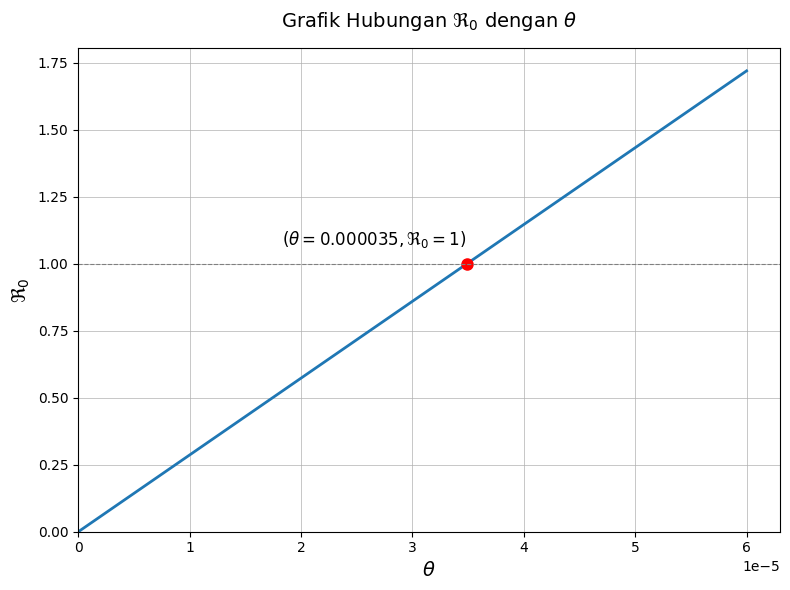

In [ ]:
# Grafik R0 terhadap Theta
import matplotlib.pyplot as plt
import numpy as np

# Nilai numerik parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.6
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Menghitung nilai gradien
gradien_D = (alpha * beta * m2) / (mu * m1 * m3 * m4)

# Titik kritis (saat R0 = 1)
theta_kritis = 1 / gradien_D

# Menampilkan nilai perhitungan sebagai output
print("=== HASIL PERHITUNGAN NUMERIK ===")
print(f"1. Persamaan Garis      : R0 = {gradien_D:.6f} * theta")
print(f"2. Titik Kritis (R0=1)  : theta = {theta_kritis:.6f}")
print("===================================")

# Membuat grafik
theta_values = np.linspace(0, 0.00006, 100)
r0_values = gradien_D * theta_values

plt.figure(figsize=(8, 6))

# Plot garis biru
plt.plot(theta_values, r0_values, label=r'$\Re_0$', color='#1f77b4', linewidth=2)

# Plot titik merah (Titik Kritis)
plt.plot(theta_kritis, 1, 'ro', markersize=8)

# Label pada titik merah
label_text = fr'$(\theta= {theta_kritis:.6f}, \Re_0 = 1)$'
plt.text(theta_kritis, 1.05, label_text, fontsize=12, ha='right', va='bottom', color='black')

# Grafik
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$\Re_0$', fontsize=14)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(left=0)
plt.ylim(bottom=0)

# Judul gambar
plt.title(r'Grafik Hubungan $\Re_0$ dengan $\theta$', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig('grafik_final_measles.png', dpi=300)
plt.show()

Titik Kritis: omega = 0.00042


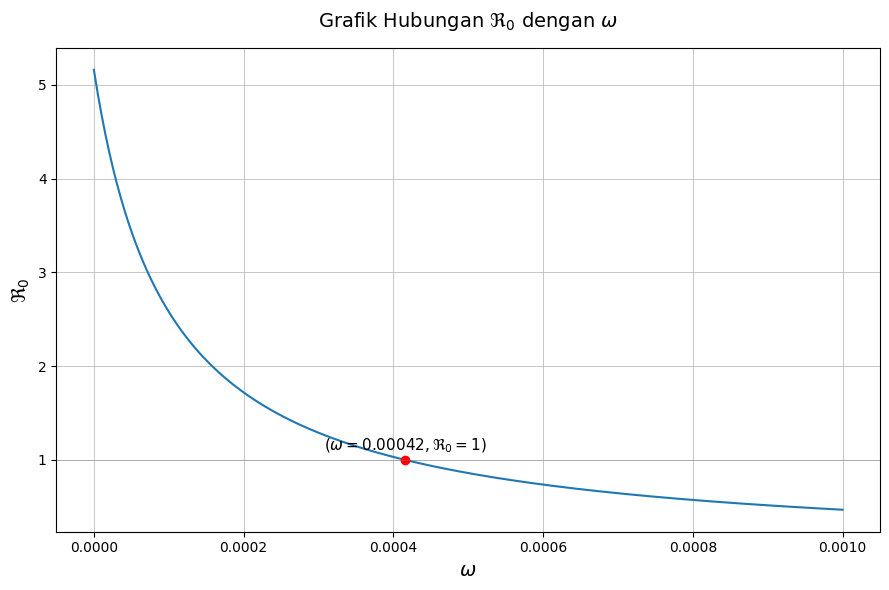

In [ ]:
# Grafik R0 terhadap Omega
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Nilai numerik parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
alpha   = 0.6
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Fungsi R0
def hitung_r0(omega_val):
    # Variabel turunan yang mengandung omega
    m1 = mu + beta
    m3 = mu + delta + rho_e + rho_d + gamma_n
    # Rumus R0 Lengkap
    pembilang = alpha * theta * beta * (mu + tau)
    penyebut  = mu * (mu + omega_val + tau) * m1 * m3
    return pembilang / penyebut

# Mencari titik kritis (R0 = 1)
tebakan_awal = 0.0005
omega_kritis = fsolve(lambda m: hitung_r0(m) - 1, tebakan_awal)[0]

print(f"Titik Kritis: omega = {omega_kritis:.5f}")

# Plotting
omega_values = np.linspace(0, 0.001, 200)
r0_values = hitung_r0(omega_values)

plt.figure(figsize=(9, 6))

# Plot kurva biru
plt.plot(omega_values, r0_values, label=r'$\Re_0$', color='#1f77b4', linewidth=1.5)

# Plot titik merah
plt.plot(omega_kritis, 1, 'ro', markersize=6)

# Label titik
label_text = fr'$(\omega = {omega_kritis:.5f}, \Re_0 = 1)$'
plt.text(omega_kritis, 1.05, label_text, fontsize=11, ha='center', va='bottom', color='black')

# Grid & label sumbu
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xlabel(r'$\omega$', fontsize=14)
plt.ylabel(r'$\Re_0$', fontsize=14)

plt.axhline(y=1, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Judul gambar
plt.title(r'Grafik Hubungan $\Re_0$ dengan $\omega$', fontsize=14, pad=15)

# Menyimpan gambar
plt.tight_layout()
plt.savefig('grafik_r0_omega_final.png', dpi=300)
plt.show()

Titik Kritis rho_e: 0.06103
Titik Kritis rho_d: 0.09103


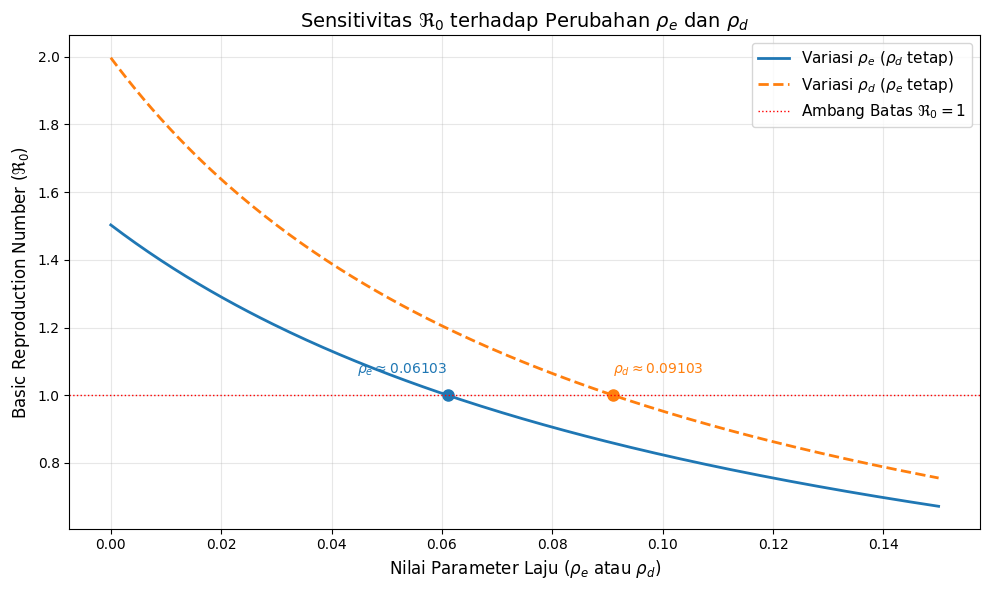

In [ ]:
# Grafik R0 terhadap Rho_e dan Rho_d
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Nilai numerik parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.6
beta    = 0.1
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Nilai numerik awal rho_e dan rho_d
rho_e_default = 0.02
rho_d_default = 0.05

# Mendefinisikan fungsi R0
# Fungsi R0 terhadap rho_e (rho_d dianggap tetap)
def hitung_r0_rho_e(rho_e_val):
    m1 = mu + beta
    m3 = mu + delta + rho_e_val + rho_d_default + gamma_n
    pembilang = alpha * theta * beta * (mu + tau)
    penyebut  = mu * (mu + omega + tau) * m1 * m3
    return pembilang / penyebut

# Fungsi R0 terhadap rho_d (rho_e dianggap tetap)
def hitung_r0_rho_d(rho_d_val):
    m1 = mu + beta
    m3 = mu + delta + rho_e_default + rho_d_val + gamma_n
    pembilang = alpha * theta * beta * (mu + tau)
    penyebut  = mu * (mu + omega + tau) * m1 * m3
    return pembilang / penyebut

# Mencari titik kritis (R0 = 1)
tebakan_awal = 0.1
rho_e_kritis = fsolve(lambda r: hitung_r0_rho_e(r) - 1, tebakan_awal)[0]
rho_d_kritis = fsolve(lambda r: hitung_r0_rho_d(r) - 1, tebakan_awal)[0]

print(f"Titik Kritis rho_e: {rho_e_kritis:.5f}")
print(f"Titik Kritis rho_d: {rho_d_kritis:.5f}")

# Setup Canvas
plt.figure(figsize=(10, 6))

# Domain nilai x
x_values = np.linspace(0, 0.15, 200)

# 1. Plot Kurva rho_e (Biru Solid)
plt.plot(x_values, hitung_r0_rho_e(x_values), label=r'Variasi $\rho_e$ ($\rho_d$ tetap)',
         color='#1f77b4', linewidth=2)
# Titik kritis rho_e
plt.plot(rho_e_kritis, 1, 'o', color='#1f77b4', markersize=8)
plt.text(rho_e_kritis, 1.05, fr'$\rho_e \approx {rho_e_kritis:.5f}$',
         color='#1f77b4', ha='right', va='bottom', fontsize=10, fontweight='bold')

# 2. Plot Kurva rho_d (Oranye Putus-putus)
plt.plot(x_values, hitung_r0_rho_d(x_values), label=r'Variasi $\rho_d$ ($\rho_e$ tetap)',
         color='#ff7f0e', linewidth=2, linestyle='--')
# Titik kritis rho_d
plt.plot(rho_d_kritis, 1, 'o', color='#ff7f0e', markersize=8)
plt.text(rho_d_kritis, 1.05, fr'$\rho_d \approx {rho_d_kritis:.5f}$',
         color='#ff7f0e', ha='left', va='bottom', fontsize=10, fontweight='bold')

# Garis ambang batas R0 = 1 (Merah tipis)
plt.axhline(y=1, color='red', linestyle=':', linewidth=1, label=r'Ambang Batas $\Re_0 = 1$')

# Label dan Judul
plt.xlabel(r'Nilai Parameter Laju ($\rho_e$ atau $\rho_d$)', fontsize=12)
plt.ylabel(r'Basic Reproduction Number ($\Re_0$)', fontsize=12)
plt.title(r'Sensitivitas $\Re_0$ terhadap Perubahan $\rho_e$ dan $\rho_d$', fontsize=14)

# Grid, Legend, Layout
plt.grid(True, which='both', linestyle='-', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

# Menyimpan Gambar
plt.savefig('grafik_r0_combined.png', dpi=300)
plt.show()

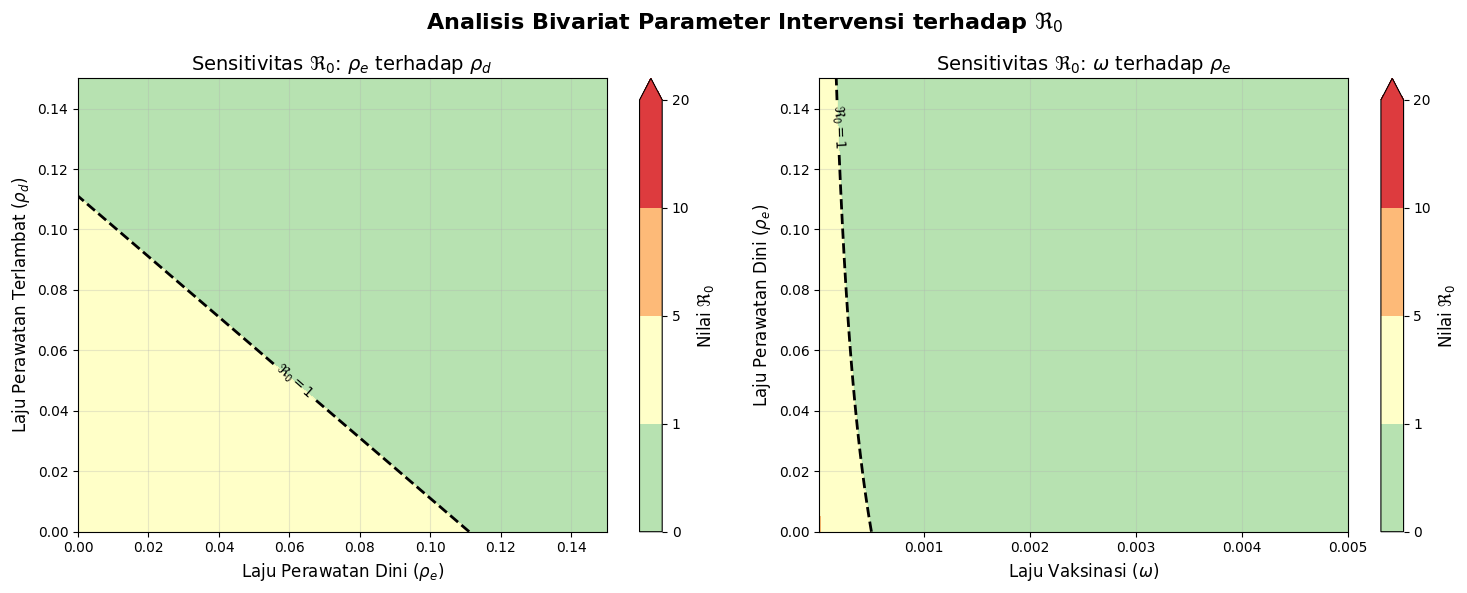

In [ ]:
# Analisis Bivariat Parameter Terhadap R0
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Nilai numerik parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
alpha   = 0.6
beta    = 0.1
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Nilai numerik awal omega, rho_e, dan rho_d
rho_e_default = 0.02
rho_d_default = 0.05
omega0  = 0.0003

# Mendefinisikan fungsi R0
def hitung_r0_bivariat(omega_val, rho_e_val, rho_d_val):
    m1 = mu + beta
    m3 = mu + delta + rho_e_val + rho_d_val + gamma_n
    pembilang = alpha * theta * beta * (mu + tau)
    penyebut  = mu * (mu + omega_val + tau) * m1 * m3
    return pembilang / penyebut

# Domain nilai (Grid)
x_vals = np.linspace(0, 0.15, 300)
y_vals = np.linspace(0, 0.15, 300)
omega_vals = np.linspace(0.00001, 0.005, 300)

RE1, RD = np.meshgrid(x_vals, y_vals)
Z1 = hitung_r0_bivariat(omega0, RE1, RD)

OM, RE2 = np.meshgrid(omega_vals, x_vals)
Z2 = hitung_r0_bivariat(OM, RE2, rho_d_default)

# Setup Canvas
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
levels = [0, 1, 5, 10, 20]
colors = ['#abdda4', '#ffffbf', '#fdae61', '#d7191c']

# 1. Plot Panel 1 (rho_e vs rho_d)
cf1 = ax[0].contourf(RE1, RD, Z1, levels=levels, colors=colors, extend='max', alpha=0.85)
c1  = ax[0].contour(RE1, RD, Z1, levels=[1], colors='black', linewidths=2, linestyles='dashed')
ax[0].clabel(c1, fmt=r'$\Re_0=1$', inline=True, fontsize=10)

# Label dan Judul Panel 1
ax[0].set_title(r'Sensitivitas $\Re_0$: $\rho_e$ terhadap $\rho_d$', fontsize=14)
ax[0].set_xlabel(r'Laju Perawatan Dini ($\rho_e$)', fontsize=12)
ax[0].set_ylabel(r'Laju Perawatan Terlambat ($\rho_d$)', fontsize=12)

# Grid, Legend, Layout Panel 1
ax[0].grid(True, which='both', linestyle='-', alpha=0.3)
fig.colorbar(cf1, ax=ax[0]).set_label(r'Nilai $\Re_0$', fontsize=12)

# 2. Plot Panel 2 (omega vs rho_e)
cf2 = ax[1].contourf(OM, RE2, Z2, levels=levels, colors=colors, extend='max', alpha=0.85)
c2  = ax[1].contour(OM, RE2, Z2, levels=[1], colors='black', linewidths=2, linestyles='dashed')
ax[1].clabel(c2, fmt=r'$\Re_0=1$', inline=True, fontsize=10)

# Label dan Judul Panel 2
ax[1].set_title(r'Sensitivitas $\Re_0$: $\omega$ terhadap $\rho_e$', fontsize=14)
ax[1].set_xlabel(r'Laju Vaksinasi ($\omega$)', fontsize=12)
ax[1].set_ylabel(r'Laju Perawatan Dini ($\rho_e$)', fontsize=12)

# Grid, Legend, Layout Panel 2
ax[1].grid(True, which='both', linestyle='-', alpha=0.3)
fig.colorbar(cf2, ax=ax[1]).set_label(r'Nilai $\Re_0$', fontsize=12)

# Label dan Judul Utama
fig.suptitle(r'Analisis Bivariat Parameter Intervensi terhadap $\Re_0$', fontsize=16, fontweight='bold')

# Layout
plt.tight_layout()

# Menyimpan Gambar
plt.savefig('grafik_kontur_bivariat_r0.png', dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Nilai numerik Parameter
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.02
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Mendefinisikan variabel perantara m1, m2, m3, dan m4
m1 = mu + beta
m2 = mu + tau
m3 = mu + delta + rho_e + rho_d + gamma_n
m4 = mu + omega + tau

# Mendefinisikan Rumus R0 (Bilangan Reproduksi Dasar)
R0 = (alpha * theta * beta * m2) / (mu * m1 * m3 * m4)

# Menampilkan Nilai
S_0 = (theta*(mu+tau))/(mu*(mu+omega+tau))
V_0 = (omega*theta)/(mu*(mu+omega+tau))
print(S_0)
print(V_0)
print(R0)

0.30405405405405406
0.9121621621621623
0.04300948734777992


In [ ]:
import numpy as np

# Matriks Jacobian Numerik
J = np.array([
    [-0.000337,  0.000063,  0.000000, -0.006081,  0.000000,  0.000000,  0.000000,  0.000000], # Baris S
    [ 0.000300, -0.000100,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # Baris V
    [ 0.000000,  0.000000, -0.100037,  0.006081,  0.000000,  0.000000,  0.000000,  0.000000], # Baris E
    [ 0.000000,  0.000000,  0.100000, -0.141337,  0.000000,  0.000000,  0.000000,  0.000000], # Baris I
    [ 0.000000,  0.000000,  0.000000,  0.020000, -0.142337,  0.000000,  0.000000,  0.000000], # Baris Te
    [ 0.000000,  0.000000,  0.000000,  0.050000,  0.000000, -0.150337,  0.000000,  0.000000], # Baris Td
    [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.150000, -0.142337,  0.000000], # Baris H
    [ 0.000000,  0.000000,  0.000000,  0.071000,  0.142000,  0.000000,  0.142000, -0.000037]  # Baris R
])

# Menghitung Nilai Eigen
nilai_eigen = np.linalg.eigvals(J)

# Menampilkan Hasil
print("=== NILAI EIGEN ===")
# Urutkan dari yang terbesar (secara nilai real
nilai_eigen_sorted = np.sort(nilai_eigen)[::-1]

for i, eigen in enumerate(nilai_eigen_sorted, 1):
    # Format desimal agar rapi
    print(f"Lambda_{i} = {eigen:.6f}")

# Cek Kestabilan Otomatis
if all(e.real < 0 for e in nilai_eigen):
    print("\nKESIMPULAN: Titik Ekuilibrium Stabil Asimtotik (Semua Eigen Negatif)")
else:
    print("\nKESIMPULAN: Titik Ekuilibrium Tidak Stabil (Ada Eigen Positif)")

=== NILAI EIGEN ===
Lambda_1 = -0.000037
Lambda_2 = -0.000037
Lambda_3 = -0.000400
Lambda_4 = -0.088523
Lambda_5 = -0.142337
Lambda_6 = -0.142337
Lambda_7 = -0.150337
Lambda_8 = -0.152851

KESIMPULAN: Titik Ekuilibrium Stabil Asimtotik (Semua Eigen Negatif)


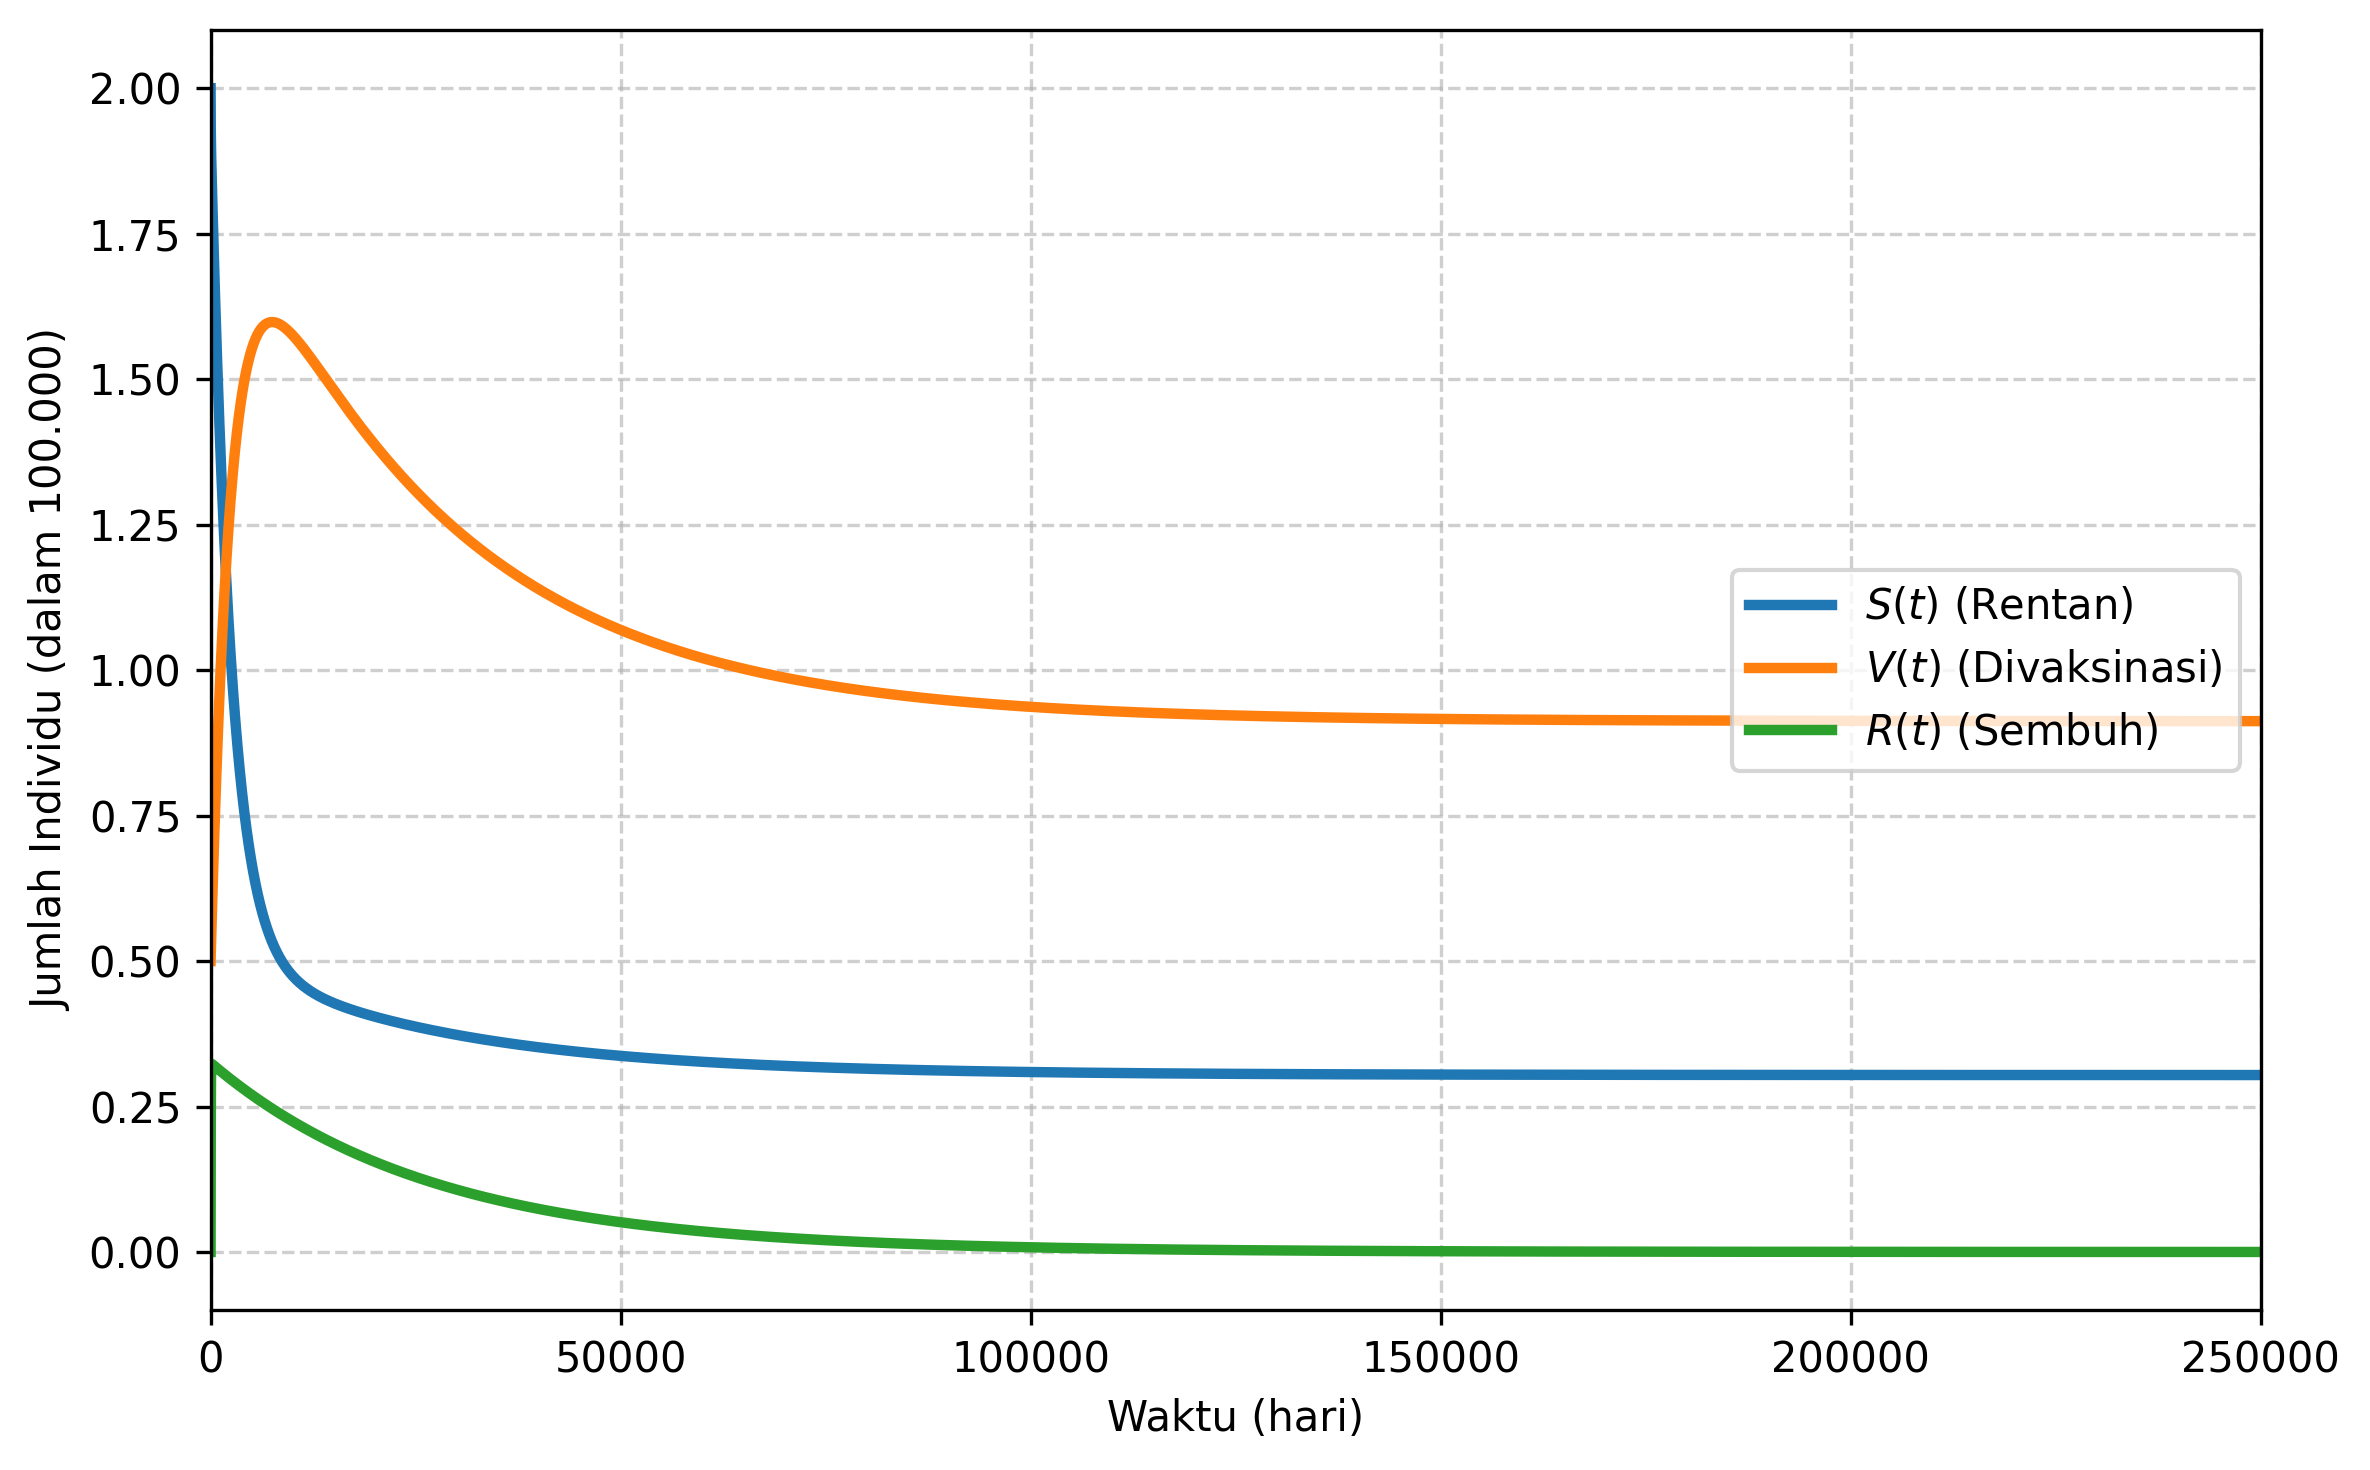

Final values at t = 250000.0:
S(t) = 0.3040742018079336
V(t) = 0.9122581038720009
E(t) = 0.0
I(t) = 0.0
T_e(t) = 0.0
T_d(t) = 0.0
H(t) = 0.0
R(t) = 3.125664873334577e-05


In [ ]:
# Visualisasi Grafik Bebas Penyakit
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    alpha   = 0.02          # Nilai alpha rendah agar R0 < 1 (Kondisi Bebas Penyakit)
    beta    = 0.1
    rho_e   = 0.02
    rho_d   = 0.05
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.15

    # Sistem persamaan diferensial
    N = S + V + E + I + T_e + T_d + H + R
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [2.0, 0.5, 0.1, 0.1, 0.05, 0.0, 0.0, 0.0]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 250000, n)

# Penyelesaian sistem persamaan diferensial menggunakan metode integrasi numerik
z = odeint(model, z0, t)
z = np.clip(z, 0, None)

# Ekstraksi hasil simulasi untuk setiap subpopulasi
S   = z[:, 0]
V   = z[:, 1]
E   = z[:, 2]
I   = z[:, 3]
T_e = z[:, 4]
T_d = z[:, 5]
H   = z[:, 6]
R   = z[:, 7]

# Visualisasi hasil simulasi
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(t, S, label='$S(t)$ (Rentan)', color='#1f77b4', linewidth=2.5)
plt.plot(t, V, label='$V(t)$ (Divaksinasi)', color='#FF7F0E', linewidth=2.5)
plt.plot(t, R, label='$R(t)$ (Sembuh)', color='#2CA02C', linewidth=2.5)
#plt.plot(t, E, label='$E(t)$', color='#ff7f0e')
#plt.plot(t, I, label='$I(t)$', color='#d62728')
#plt.plot(t, T_e, label='$T_e(t)$', color='#9467bd')
#plt.plot(t, T_d, label='$T_d(t)$', color='#e377c2')
#plt.plot(t, H, label='$H(t)$', color='#8c564b')

# Pengaturan label dan legenda grafik
plt.ylabel('Jumlah Individu (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.xlim(0, 250000)
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('TitikEkuilibriumBebasPenyakit_Makro.png', dpi=300)
plt.show()

# Menampilkan nilai akhir hasil simulasi
print(f"Final values at t = {t[-1]}:")
print(f"S(t) = {S[-1]}")
print(f"V(t) = {V[-1]}")
print(f"E(t) = {E[-1]}")
print(f"I(t) = {I[-1]}")
print(f"T_e(t) = {T_e[-1]}")
print(f"T_d(t) = {T_d[-1]}")
print(f"H(t) = {H[-1]}")
print(f"R(t) = {R[-1]}")


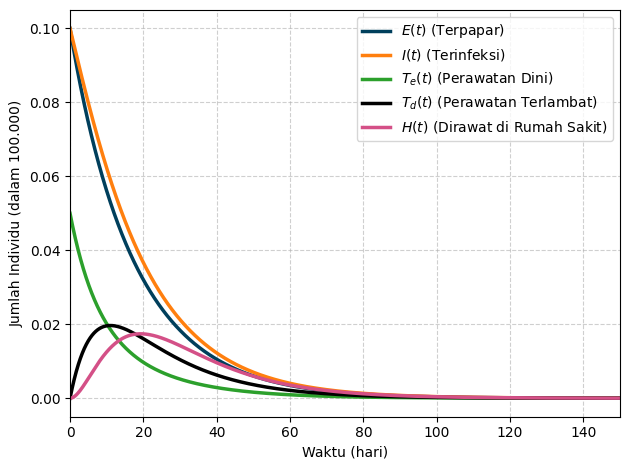

Final values at t = 150.0:
S(t) = 1.840055640562884
V(t) = 0.5769892375383597
E(t) = 2.1866533025172276e-05
I(t) = 2.578647176952482e-05
T_e(t) = 6.004135544492122e-06
T_d(t) = 1.3732741420340695e-05
H(t) = 2.3954190226293086e-05
R(t) = 0.32320642704643854


In [ ]:
# Visualisasi Grafik Bebas Penyakit (Jangka Pendek)
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    alpha   = 0.02          # Nilai alpha rendah agar R0 < 1 (Kondisi Bebas Penyakit)
    beta    = 0.1
    rho_e   = 0.02
    rho_d   = 0.05
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.15

    # Sistem persamaan diferensial
    N = S + V + E + I + T_e + T_d + H + R
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [2.0, 0.5, 0.1, 0.1, 0.05, 0.0, 0.0, 0.0]

# Rentang waktu simulasi
n = 5000
t = np.linspace(0, 150, n)

# Penyelesaian sistem persamaan diferensial menggunakan metode integrasi numerik
z = odeint(model, z0, t)
z = np.clip(z, 0, None)

# Ekstraksi hasil simulasi untuk setiap subpopulasi
S   = z[:, 0]
V   = z[:, 1]
E   = z[:, 2]
I   = z[:, 3]
T_e = z[:, 4]
T_d = z[:, 5]
H   = z[:, 6]
R   = z[:, 7]

# Visualisasi hasil simulasi
plt.plot(t, E, label='$E(t)$ (Terpapar)', color='#003f5c', linewidth=2.5)
plt.plot(t, I, label='$I(t)$ (Terinfeksi)', color='#ff7f0e', linewidth=2.5)
plt.plot(t, T_e, label='$T_e(t)$ (Perawatan Dini)', color='#2ca02c', linewidth=2.5)
plt.plot(t, T_d, label='$T_d(t)$ (Perawatan Terlambat)', color='#000000', linewidth=2.5)
plt.plot(t, H, label='$H(t)$ (Dirawat di Rumah Sakit)', color='#d45087', linewidth=2.5)
#plt.plot(t, S, label='$S(t)$', color='#1f77b4')
#plt.plot(t, V, label='$V(t)$', color='#2ca02c')
#plt.plot(t, R, label='$R(t)$', color='#7f7f7f')

# Pengaturan label dan legenda grafik
plt.ylabel('Jumlah Individu (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.xlim(0, 150)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('TitikEkuilibriumBebasPenyakit_Mikro.png', dpi=300)
plt.show()

# Menampilkan nilai akhir hasil simulasi
print(f"Final values at t = {t[-1]}:")
print(f"S(t) = {S[-1]}")
print(f"V(t) = {V[-1]}")
print(f"E(t) = {E[-1]}")
print(f"I(t) = {I[-1]}")
print(f"T_e(t) = {T_e[-1]}")
print(f"T_d(t) = {T_d[-1]}")
print(f"H(t) = {H[-1]}")
print(f"R(t) = {R[-1]}")

--- Analisis Analitik ---
S* = 0.3041, V* = 0.9122
R0 = 0.0430 -> Bebas Penyakit



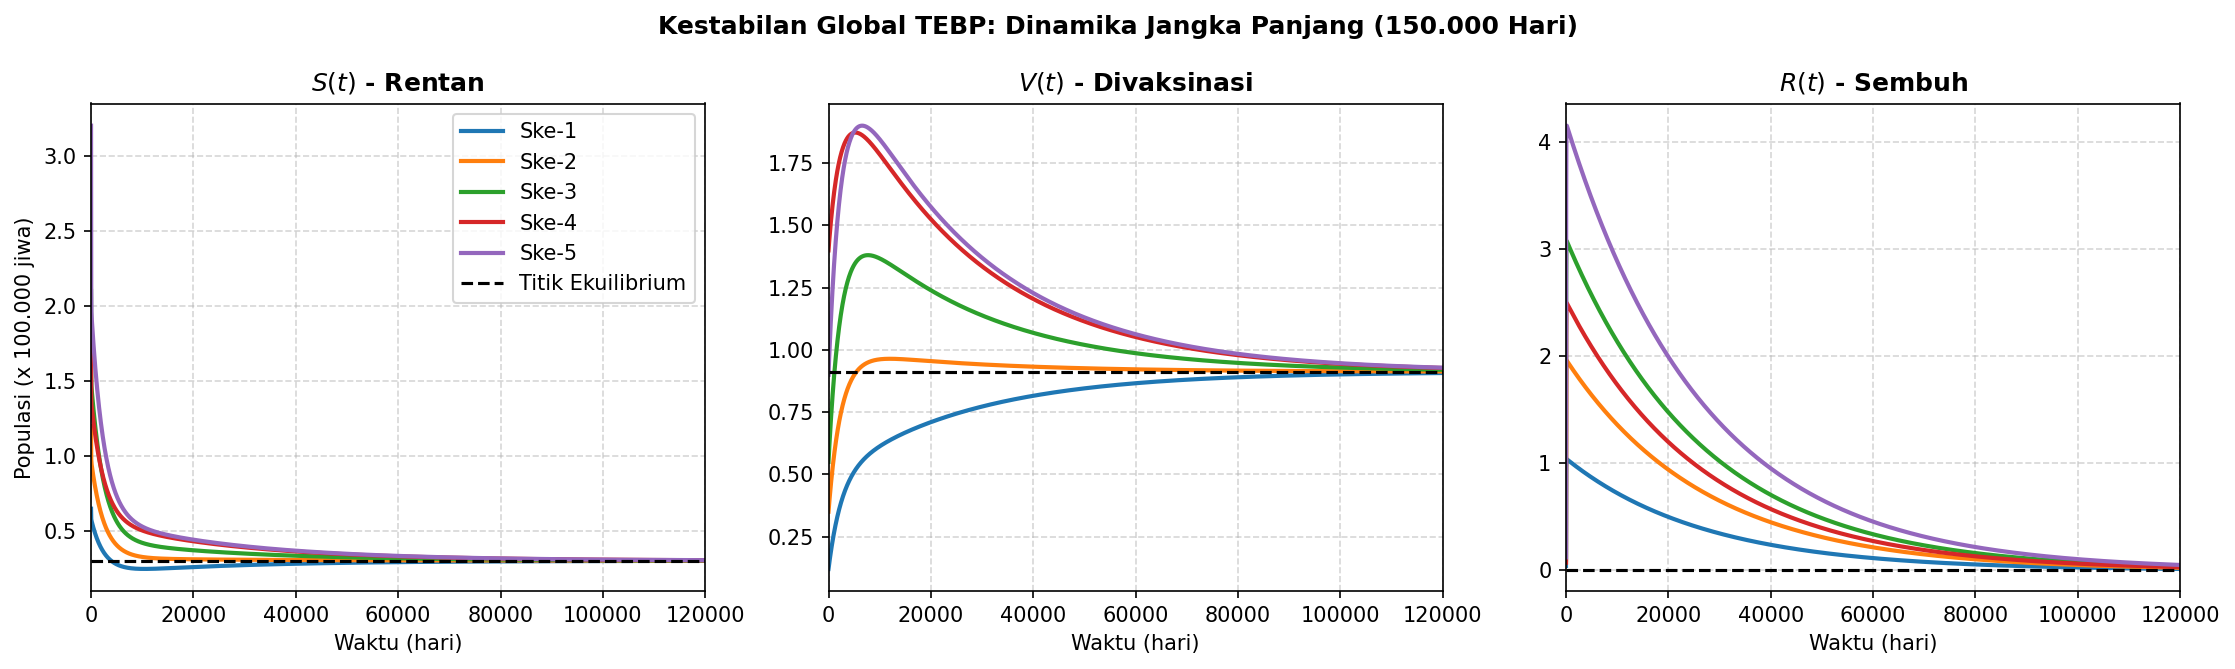

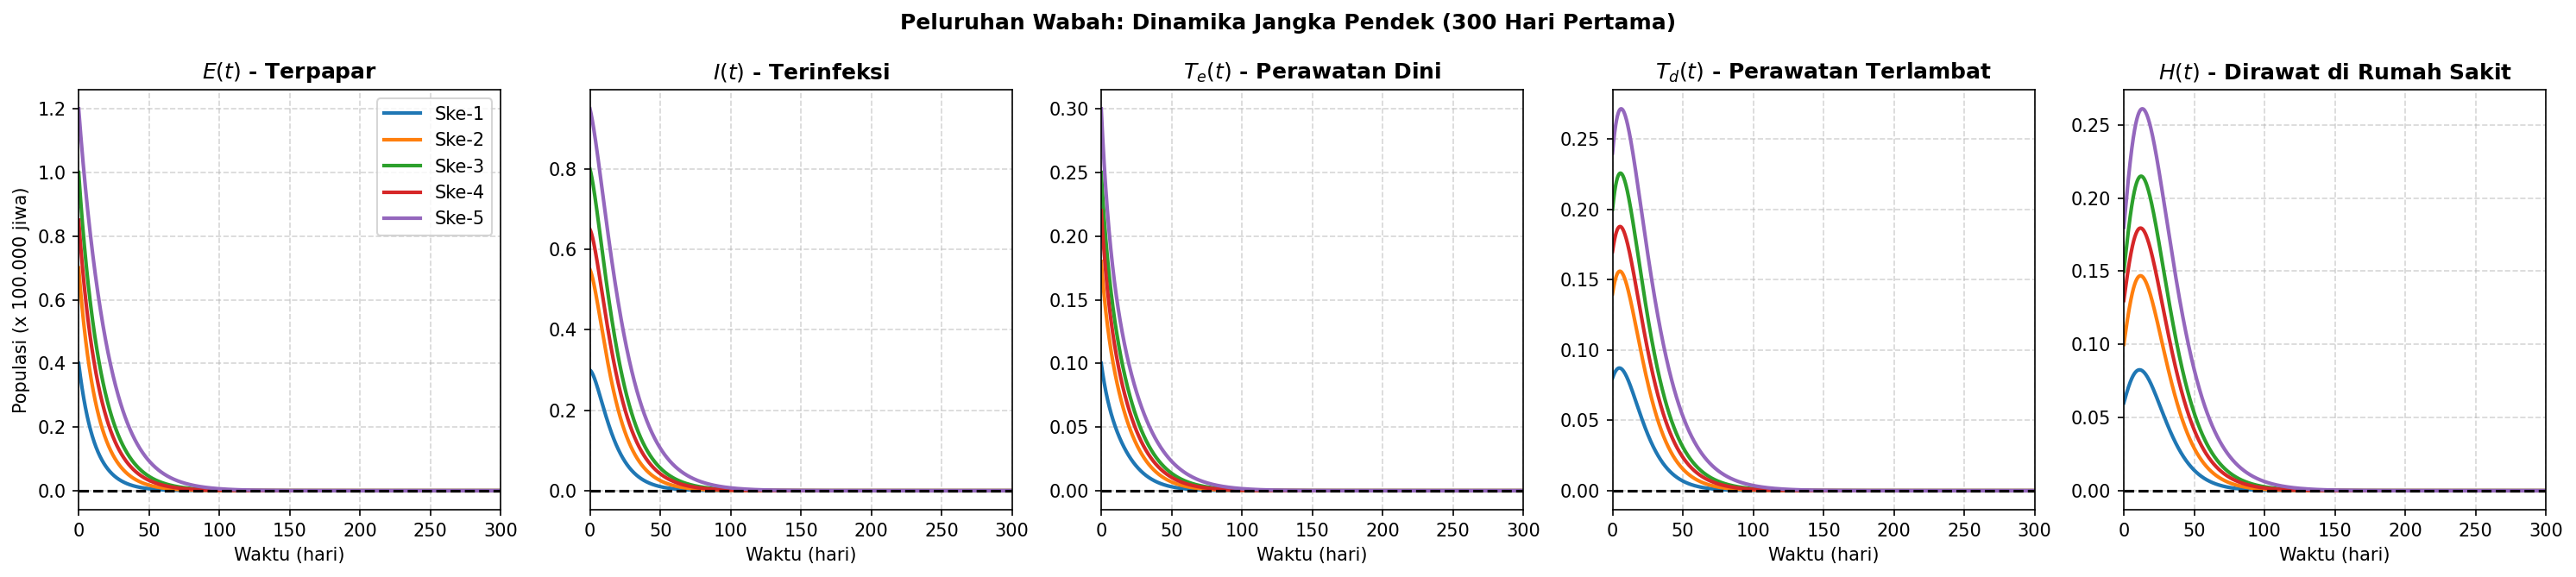

In [ ]:
# Visualisasi Grafik Bebas Penyakit Global
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Nilai parameter model
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.02
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Pendefinisian Fungsi Model Matematika
def model(z, t):
    S, V, E, I, T_e, T_d, H, R = z

    dSdt   = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt   = omega*S - (mu + tau)*V
    dEdt   = alpha*S*I - (mu + beta)*E
    dIdt   = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt   = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt   = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    return [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]

# Analisis TEBP dan R0
S_star = (theta * (mu + tau)) / (mu * (mu + omega + tau))
V_star = (omega * S_star) / (mu + tau)
TEBP   = [S_star, V_star, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

k1 = mu + beta
k2 = mu + delta + rho_e + rho_d + gamma_n
R0 = (alpha * S_star * beta) / (k1 * k2)

print(f"--- Analisis Analitik ---")
print(f"S* = {S_star:.4f}, V* = {V_star:.4f}")
print(f"R0 = {R0:.4f} -> {'Bebas Penyakit' if R0 < 1 else 'Endemik'}\n")

# Nilai awal dan solusi numerik
z0_list = [
    [0.65, 0.12, 0.40, 0.30, 0.10, 0.08, 0.06, 0.04],
    [1.20, 0.35, 0.70, 0.55, 0.18, 0.14, 0.10, 0.08],
    [2.10, 0.55, 1.00, 0.80, 0.25, 0.20, 0.15, 0.10],
    [1.80, 1.40, 0.85, 0.65, 0.22, 0.17, 0.13, 0.07],
    [3.20, 0.90, 1.20, 0.95, 0.30, 0.24, 0.18, 0.12],
]

# Waktu simulasi
t_long  = np.linspace(0, 120000, 3000)
t_short = np.linspace(0, 300, 2000)

sol_long, sol_short = [], []
for z0 in z0_list:
    sol_long.append(np.clip(odeint(model, z0, t_long), 0, None))
    sol_short.append(np.clip(odeint(model, z0, t_short), 0, None))

# Fungsi utilitas visualisasi
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
labels = [f"Ske-{i+1}" for i in range(len(z0_list))]

def setup_axes(ax, x_max, xlabel='Waktu (hari)'):
    ax.set_xlim(0, x_max)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel(xlabel)

# Visualisasi hasil simulasi jangka panjang
fig1, axs1 = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)
# Format: (indeks_z, 'Judul', indeks_tebp) - Perhatikan indeks R adalah 7
comps_SVR = [(0, '$S(t)$ - Rentan', 0), (1, '$V(t)$ - Divaksinasi', 1), (7, '$R(t)$ - Sembuh', 7)]

for col, (idx_z, title, idx_tebp) in enumerate(comps_SVR):
    ax = axs1[col]
    for i, z in enumerate(sol_long):
        ax.plot(t_long, z[:, idx_z], color=colors[i], lw=2, label=labels[i] if col==0 else "")

    ax.axhline(TEBP[idx_tebp], color='k', ls='--', lw=1.5, label='Titik Ekuilibrium' if col==0 else "")
    ax.set_title(title, fontweight='bold')
    setup_axes(ax, 120000)

    if col == 0:
        ax.set_ylabel('Populasi (x 100.000 jiwa)')
        ax.legend(loc='best')

fig1.suptitle('Kestabilan Global TEBP: Dinamika Jangka Panjang (150.000 Hari)', fontweight='bold')
plt.tight_layout()
plt.savefig('TEBP_Makro.png', dpi=300)
plt.show()

# Visualisasi hasil simulasi jangka pendek
fig2, axs2 = plt.subplots(1, 5, figsize=(20, 4.5), dpi=150)
comps_dis = [(2, '$E(t)$ - Terpapar'), (3, '$I(t)$ - Terinfeksi'),
             (4, '$T_e(t)$ - Perawatan Dini'), (5, '$T_d(t)$ - Perawatan Terlambat'), (6, '$H(t)$ - Dirawat di Rumah Sakit')]

for col, (idx_z, title) in enumerate(comps_dis):
    ax = axs2[col]
    for i, z in enumerate(sol_short):
        ax.plot(t_short, z[:, idx_z], color=colors[i], lw=2, label=labels[i] if col==0 else "")

    ax.axhline(0, color='k', ls='--', lw=1.5)
    ax.set_title(title, fontweight='bold')
    setup_axes(ax, 300)

    if col == 0:
        ax.set_ylabel('Populasi (x 100.000 jiwa)')
        ax.legend(loc='best')

fig2.suptitle('Peluruhan Wabah: Dinamika Jangka Pendek (300 Hari Pertama)', fontweight='bold')
plt.tight_layout()
plt.savefig('TEBP_Mikro.png', dpi=300)
plt.show()

In [ ]:
import numpy as np

# Nilai numerik parameter untuk Endemik
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.6
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Definisikan Konstanta k dan m
k3 = mu + beta
k4 = mu + delta + rho_e + rho_d + gamma_n
k5 = gamma_e + mu + delta
k6 = mu + delta + kappa
k7 = gamma_H + delta + mu
mu_plus_tau = mu + tau
mu_omega_tau = mu + omega + tau

S_star = (k3 * k4) / (alpha * beta)
term1_I = (theta * beta) / (k3 * k4)
term2_I = (mu * mu_omega_tau) / (alpha * mu_plus_tau)
I_star = term1_I - term2_I
V_star = (omega * S_star) / mu_plus_tau
E_star = (k4 / beta) * I_star
Te_star = (rho_e / k5) * I_star
Td_star = (rho_d / k6) * I_star
H_star = (kappa / k7) * Td_star
R_star_term1 = (gamma_e * rho_e) / k5
R_star_term2 = (gamma_H * kappa * rho_d) / (k7 * k6)
R_star_num_total = R_star_term1 + R_star_term2 + gamma_n
R_star_factor = R_star_num_total / mu
R_star = R_star_factor * I_star

# Output final
E_star_vector = [S_star, V_star, E_star, I_star, Te_star, Td_star, H_star, R_star]
E_star_rounded = [f"{x:.6f}" for x in E_star_vector]

# Mendefinisikan Rumus R0
R0 = (alpha * theta * beta * (mu + tau)) / (mu * m1 * m3 * (mu + omega + tau))
print(R0)

print("=== KOORDINAT TITIK EKUILIBRIUM ENDEMIK (E*) ===")
print(f"E* = (S*, V*, E*, I*, Te*, Td*, H*, R*)")
print(f"E* = ({', '.join(E_star_rounded)})")


1.2902846204333978
=== KOORDINAT TITIK EKUILIBRIUM ENDEMIK (E*) ===
E* = (S*, V*, E*, I*, Te*, Td*, H*, R*)
E* = (0.235649, 0.706946, 0.000101, 0.000072, 0.000010, 0.000024, 0.000025, 0.272330)


In [ ]:
import numpy as np

# Matriks Jacobian Numerik
J = np.array([
    [-0.000380,  0.000063,  0.000000, -0.141389,  0.000000,  0.000000,  0.000000,  0.000000], # Baris S
    [ 0.000300, -0.000100,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000], # Baris V
    [ 0.000043,  0.000000, -0.100037,  0.141389,  0.000000,  0.000000,  0.000000,  0.000000], # Baris E
    [ 0.000000,  0.000000,  0.100000, -0.141337,  0.000000,  0.000000,  0.000000,  0.000000], # Baris I
    [ 0.000000,  0.000000,  0.000000,  0.020000, -0.142337,  0.000000,  0.000000,  0.000000], # Baris Te
    [ 0.000000,  0.000000,  0.000000,  0.050000,  0.000000, -0.150337,  0.000000,  0.000000], # Baris Td
    [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.150000, -0.142337,  0.000000], # Baris H
    [ 0.000000,  0.000000,  0.000000,  0.071000,  0.142000,  0.000000,  0.142000, -0.000037]  # Baris R
])

# Menghitung Nilai Eigen
nilai_eigen = np.linalg.eigvals(J)

# Menampilkan Hasil
print("=== NILAI EIGEN ===")
# Urutkan dari yang terbesar (secara nilai real)
nilai_eigen_sorted = np.sort(nilai_eigen)[::-1]

for i, eigen in enumerate(nilai_eigen_sorted, 1):
    # Format desimal agar rapi
    print(f"Lambda_{i} = {eigen:.6f}")

# Cek Kestabilan Otomatis
if all(e.real < 0 for e in nilai_eigen):
    print("\nKESIMPULAN: Titik Ekuilibrium Stabil Asimtotik (Semua Eigen Negatif)")
else:
    print("\nKESIMPULAN: Titik Ekuilibrium Tidak Stabil (Ada Eigen Positif)")

=== NILAI EIGEN ===
Lambda_1 = -0.000037+0.000000j
Lambda_2 = -0.000101+0.000000j
Lambda_3 = -0.000184+0.001570j
Lambda_4 = -0.000184-0.001570j
Lambda_5 = -0.142337+0.000000j
Lambda_6 = -0.142337+0.000000j
Lambda_7 = -0.150337+0.000000j
Lambda_8 = -0.241384+0.000000j

KESIMPULAN: Titik Ekuilibrium Stabil Asimtotik (Semua Eigen Negatif)


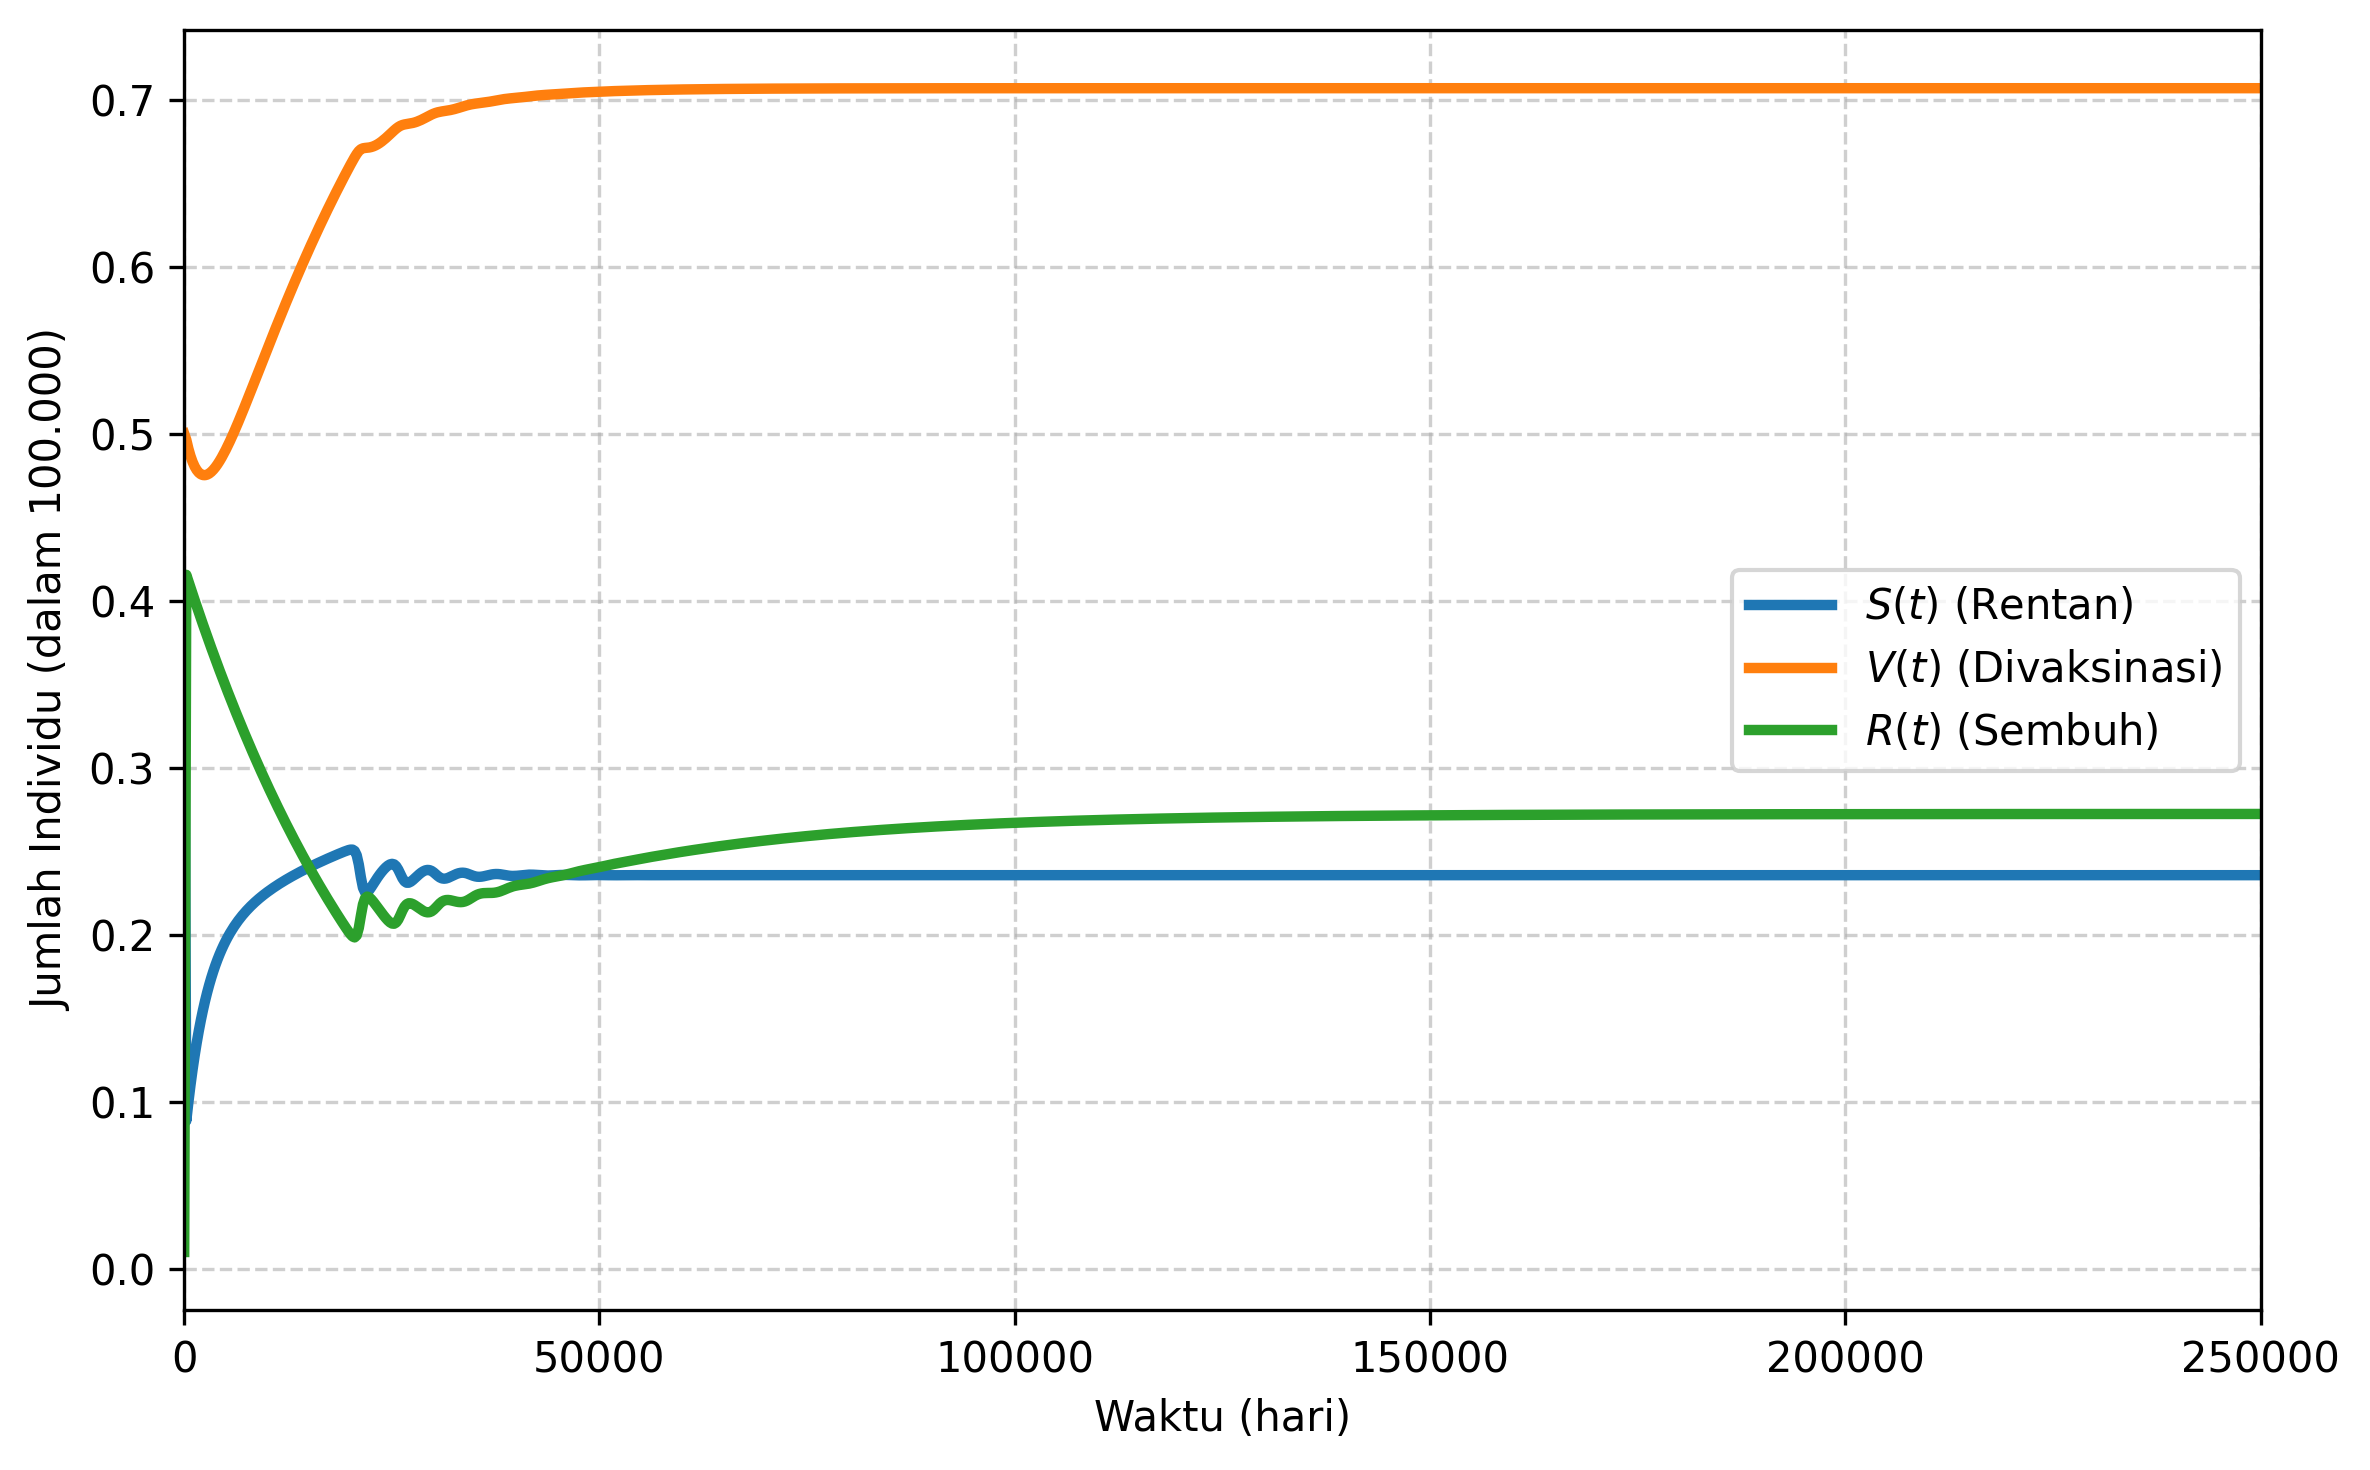

Final values at t = 250000.0:
S(t) = 0.23564882144323085
V(t) = 0.7069464737427587
E(t) = 0.00010120232254613753
I(t) = 7.160355963833934e-05
T_e(t) = 1.0061130980155713e-05
T_d(t) = 2.3814350424744485e-05
H(t) = 2.509644423083368e-05
R(t) = 0.27230972807205467


In [ ]:
# Visualisasi Grafik Endemik
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    alpha   = 0.6
    beta    = 0.1
    rho_e   = 0.02
    rho_d   = 0.05
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.15

    # Sistem persamaan diferensial
    N = S + V + E + I + T_e + T_d + H + R
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [0.4, 0.5, 0.01, 0.05, 0.01, 0.01, 0.01, 0.01]

# Rentang waktu simulasi
n = 1000
t = np.linspace(0, 250000, n)

# Penyelesaian sistem persamaan diferensial menggunakan metode integrasi numerik
z = odeint(model, z0, t)
z = np.clip(z, 0, None)

# Ekstraksi hasil simulasi untuk setiap subpopulasi
S   = z[:, 0]
V   = z[:, 1]
E   = z[:, 2]
I   = z[:, 3]
T_e = z[:, 4]
T_d = z[:, 5]
H   = z[:, 6]
R   = z[:, 7]

# Visualisasi hasil simulasi
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(t, S, label='$S(t)$ (Rentan)', color='#1F77B4', linewidth=2.5)
plt.plot(t, V, label='$V(t)$ (Divaksinasi)', color='#FF7F0E', linewidth=2.5)
plt.plot(t, R, label='$R(t)$ (Sembuh)', color='#2CA02C', linewidth=2.5)
#plt.plot(t, E, label='$E(t)$', color='#ff7f0e')
#plt.plot(t, I, label='$I(t)$', color='#d62728')
#plt.plot(t, T_e, label='$T_e(t)$', color='#9467bd')
#plt.plot(t, T_d, label='$T_d(t)$', color='#e377c2')
#plt.plot(t, H, label='$H(t)$', color='#8c564b')

# Pengaturan label dan legenda grafik
plt.ylabel('Jumlah Individu (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.xlim(0, 250000)
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('TitikEkuilibriumEndemik_Makro.png', dpi=300)
plt.show()

# Menampilkan nilai akhir hasil simulasi
print(f"Final values at t = {t[-1]}:")
print(f"S(t) = {S[-1]}")
print(f"V(t) = {V[-1]}")
print(f"E(t) = {E[-1]}")
print(f"I(t) = {I[-1]}")
print(f"T_e(t) = {T_e[-1]}")
print(f"T_d(t) = {T_d[-1]}")
print(f"H(t) = {H[-1]}")
print(f"R(t) = {R[-1]}")



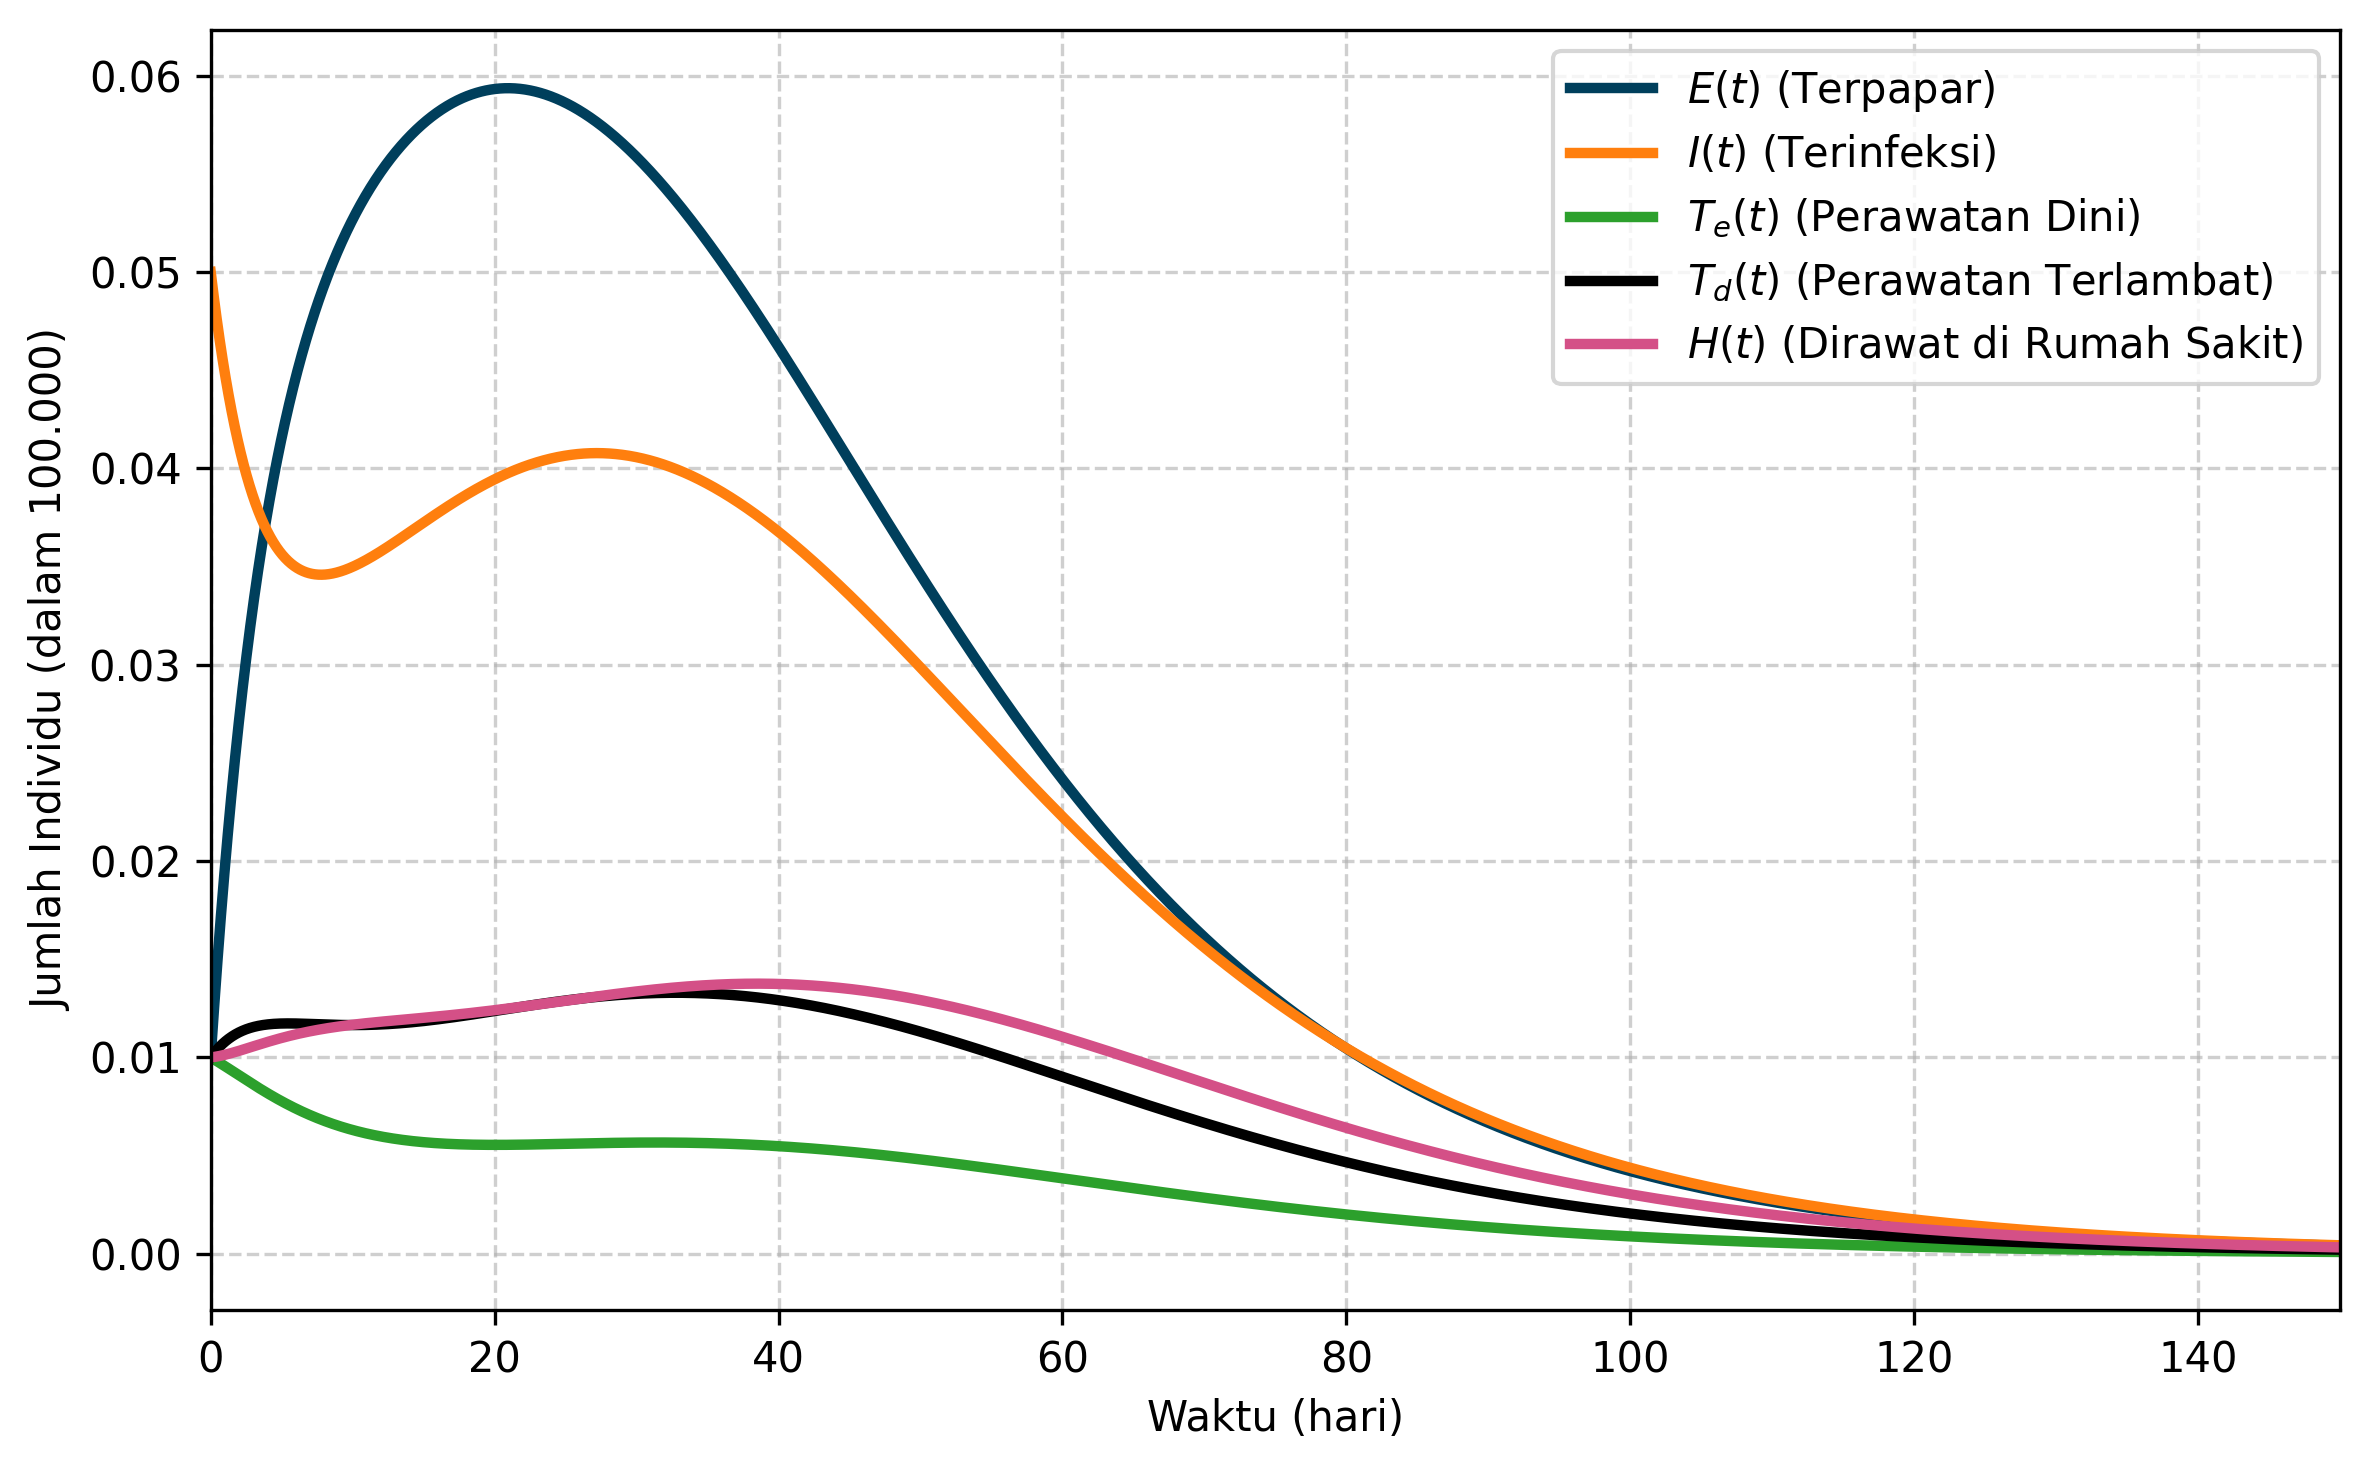

Final values at t = 150.0:
S(t) = 0.08420813561946022
V(t) = 0.49882204974802336
E(t) = 0.0004074095630183844
I(t) = 0.0004305526427007719
T_e(t) = 9.000271672995178e-05
T_d(t) = 0.00020767951866132355
H(t) = 0.0003248862269582614
R(t) = 0.4151629698543715


In [ ]:
# Visualisasi Grafik Endemik (Jangka Pendek)
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]
    [max(0, val) for val in z]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    alpha   = 0.6
    beta    = 0.1
    rho_e   = 0.02
    rho_d   = 0.05
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.15

    # Sistem persamaan diferensial
    N = S + V + E + I + T_e + T_d + H + R
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [0.4, 0.5, 0.01, 0.05, 0.01, 0.01, 0.01, 0.01]

# Rentang waktu simulasi
n = 5000
t = np.linspace(0, 150, n)

# Penyelesaian sistem persamaan diferensial menggunakan metode integrasi numerik
z = odeint(model, z0, t, hmax=0.1)
z = np.clip(z, 0, None)

# Ekstraksi hasil simulasi untuk setiap subpopulasi
S   = z[:, 0]
V   = z[:, 1]
E   = z[:, 2]
I   = z[:, 3]
T_e = z[:, 4]
T_d = z[:, 5]
H   = z[:, 6]
R   = z[:, 7]

# Visualisasi hasil simulasi
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(t, E, label='$E(t)$ (Terpapar)', color='#003f5c', linewidth=2.5)
plt.plot(t, I, label='$I(t)$ (Terinfeksi)', color='#ff7f0e', linewidth=2.5)
plt.plot(t, T_e, label='$T_e(t)$ (Perawatan Dini)', color='#2ca02c', linewidth=2.5)
plt.plot(t, T_d, label='$T_d(t)$ (Perawatan Terlambat)', color='#000000', linewidth=2.5)
plt.plot(t, H, label='$H(t)$ (Dirawat di Rumah Sakit)', color='#d45087', linewidth=2.5)
#plt.plot(t, S, label='$S(t)$', color='#1f77b4')
#plt.plot(t, V, label='$V(t)$', color='#2ca02c')
#plt.plot(t, R, label='$R(t)$', color='#7f7f7f')

# Pengaturan label dan legenda grafik
plt.ylabel('Jumlah Individu (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.xlim(0, 150)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('TitikEkuilibriumEndemik_Mikro.png', dpi=300)
plt.show()

# Menampilkan nilai akhir hasil simulasi
print(f"Final values at t = {t[-1]}:")
print(f"S(t) = {S[-1]}")
print(f"V(t) = {V[-1]}")
print(f"E(t) = {E[-1]}")
print(f"I(t) = {I[-1]}")
print(f"T_e(t) = {T_e[-1]}")
print(f"T_d(t) = {T_d[-1]}")
print(f"H(t) = {H[-1]}")
print(f"R(t) = {R[-1]}")


<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:137: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13423/1556517291.py:137: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('Simulasi Kestabilan Global Menuju Titik Ekuilibrium Endemik (TEE) | $\mathcal{R}_0 > 1$',


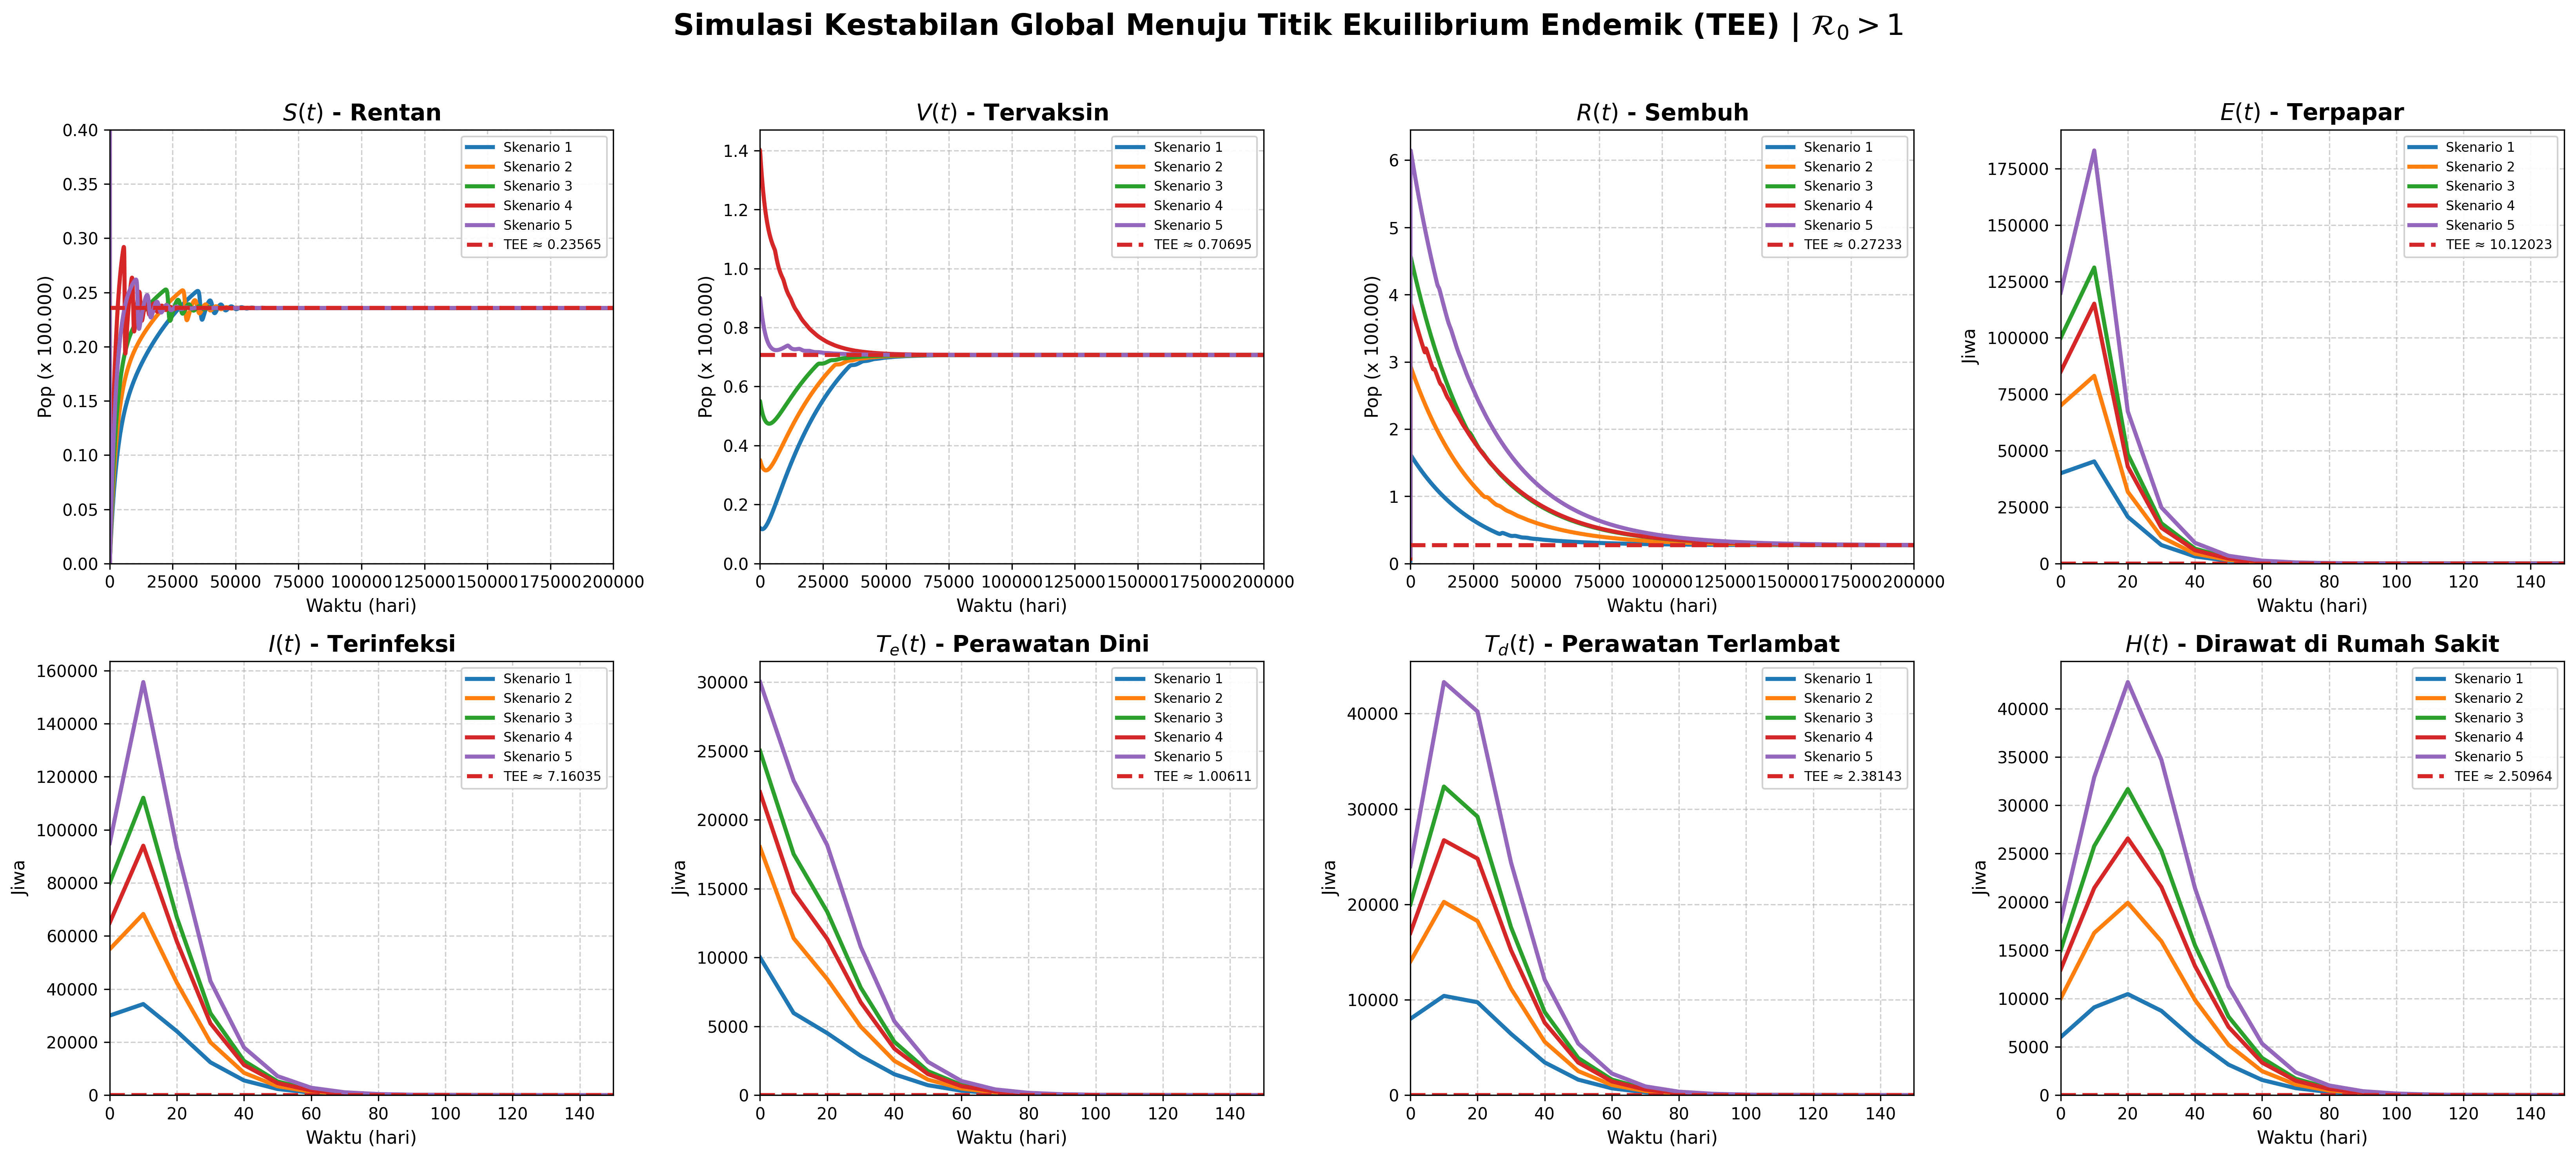

  NILAI ANALITIK TITIK EKUILIBRIUM ENDEMIK
S* = 0.235649 unit
V* = 0.706946 unit
E* = 0.000101 unit -> 10.12 Jiwa
I* = 0.000072 unit -> 7.16 Jiwa
T_e* = 0.000010 unit -> 1.01 Jiwa
T_d* = 0.000024 unit -> 2.38 Jiwa
H* = 0.000025 unit -> 2.51 Jiwa
R* = 0.272330 unit


In [ ]:
# Visualisasi Grafik Endemik (Kestabilan Global TEE)
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Nilai parameter model
theta   = 0.000045
mu      = 0.000037
delta   = 0.0003
tau     = 0.000063
omega   = 0.0003
alpha   = 0.6       # Kondisi Endemik (R0 > 1)
beta    = 0.1
rho_e   = 0.02
rho_d   = 0.05
gamma_e = 0.142
gamma_H = 0.142
gamma_n = 0.071
kappa   = 0.15

# Konstanta penyederhanaan laju keluaran
k1 = mu + beta
k2 = mu + delta + rho_e + rho_d + gamma_n
k3 = gamma_e + mu + delta
k4 = mu + delta + kappa
k5 = gamma_H + delta + mu

# Pendefinisian Fungsi Model Matematika
def model(t, z):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Sistem persamaan diferensial
    dSdt   = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt   = omega*S - (mu + tau)*V
    dEdt   = alpha*S*I - k1*E
    dIdt   = beta*E - k2*I
    dT_edt = rho_e*I - k3*T_e
    dT_ddt = rho_d*I - k4*T_d
    dHdt   = kappa*T_d - k5*H
    dRdt   = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Perhitungan Titik Ekuilibrium Endemik (TEE) Analitik
S_star  = (k1 * k2) / (alpha * beta)
V_star  = (omega * S_star) / (mu + tau)
I_star  = (theta - mu * S_star - mu * V_star) / (alpha * S_star)
E_star  = (alpha * S_star * I_star) / k1
Te_star = (rho_e * I_star) / k3
Td_star = (rho_d * I_star) / k4
H_star  = (kappa * Td_star) / k5
R_star  = (gamma_e * Te_star + gamma_H * H_star + gamma_n * I_star) / mu

TEE = [S_star, V_star, E_star, I_star, Te_star, Td_star, H_star, R_star]

# Nilai awal untuk simulasi (5 Skenario Uji Kestabilan Global)
z0_list = [
    [0.65, 0.12, 0.40, 0.30, 0.10, 0.08, 0.06, 0.04],  # Skenario 1
    [1.20, 0.35, 0.70, 0.55, 0.18, 0.14, 0.10, 0.08],  # Skenario 2
    [2.10, 0.55, 1.00, 0.80, 0.25, 0.20, 0.15, 0.10],  # Skenario 3
    [1.80, 1.40, 0.85, 0.65, 0.22, 0.17, 0.13, 0.07],  # Skenario 4
    [3.20, 0.90, 1.20, 0.95, 0.30, 0.24, 0.18, 0.12],  # Skenario 5
]

# Rentang waktu simulasi
t_span = (0, 200000)
n = 20000
t_eval = np.linspace(0, 200000, n)
sol_list = []

# Penyelesaian sistem persamaan diferensial menggunakan metode integrasi numerik BDF
for z0 in z0_list:
    res = solve_ivp(model, t_span, z0, t_eval=t_eval, method='BDF', rtol=1e-8, atol=1e-10)
    z_sol = np.clip(res.y.T, 0, None)
    sol_list.append(z_sol)

# Visualisasi hasil simulasi (Dashboard 2x4)
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']
labels = [f"Skenario {i+1}" for i in range(5)]

# Konfigurasi Grafik: (Indeks, Simbol, Nama, Skala Y, Label Y, Batas X, Batas Maks Y Khusus)
kompartemen = [
    (0, '$S(t)$', 'Rentan', 1, 'Pop (x 100.000)', 200000, 0.4),  # Y dibatasi 0.4 agar proses naik jelas
    (1, '$V(t)$', 'Tervaksin', 1, 'Pop (x 100.000)', 200000, None),
    (7, '$R(t)$', 'Sembuh', 1, 'Pop (x 100.000)', 200000, None),
    (2, '$E(t)$', 'Terpapar', 100000, 'Jiwa', 150, None),
    (3, '$I(t)$', 'Terinfeksi', 100000, 'Jiwa', 150, None),
    (4, '$T_e(t)$', 'Perawatan Dini', 100000, 'Jiwa', 150, None),
    (5, '$T_d(t)$', 'Perawatan Terlambat', 100000, 'Jiwa', 150, None),
    (6, '$H(t)$', 'Dirawat di Rumah Sakit', 100000, 'Jiwa', 150, None)
]

fig, axs = plt.subplots(2, 4, figsize=(22, 10), dpi=300)
axs = axs.flatten()

for plot_idx, (idx, simbol, nama, skala, ylabel, xmax, ymax_override) in enumerate(kompartemen):
    ax = axs[plot_idx]

    # Plot Trajektori Simulasi
    for i, z in enumerate(sol_list):
        ax.plot(t_eval, z[:, idx] * skala, color=colors[i], lw=2.5, label=labels[i])

    # Plot Garis TEE Analitik (Merah Kontras & Tebal)
    nilai_tee = TEE[idx] * skala
    ax.axhline(nilai_tee, color='#D62728', ls='--', lw=2.5, label=f'TEE ≈ {nilai_tee:.5f}')

    # Pengaturan label dan judul grafik
    ax.set_title(f'{simbol} - {nama}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Waktu (hari)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    # Pengaturan Batas X
    ax.set_xlim(0, xmax)

    # Pengaturan Batas Y (Otomatis vs Khusus)
    if ymax_override is not None:
        ax.set_ylim(0, ymax_override)
    else:
        y_data_max = max([max(z[t_eval <= xmax, idx] * skala) for z in sol_list])
        ax.set_ylim(0, max(y_data_max, nilai_tee) * 1.05)

    # Grid dan Legenda
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

# Judul Utama Keseluruhan Gambar
fig.suptitle('Simulasi Kestabilan Global Menuju Titik Ekuilibrium Endemik (TEE) | $\mathcal{R}_0 > 1$',
             fontweight='bold', fontsize=18, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('TitikEkuilibriumEndemik_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# Menampilkan nilai akhir hasil perhitungan analitik TEE
print("=" * 45)
print("  NILAI ANALITIK TITIK EKUILIBRIUM ENDEMIK")
print("=" * 45)
print(f"S* = {S_star:.6f} unit")
print(f"V* = {V_star:.6f} unit")
print(f"E* = {E_star:.6f} unit -> {E_star * 100000:.2f} Jiwa")
print(f"I* = {I_star:.6f} unit -> {I_star * 100000:.2f} Jiwa")
print(f"T_e* = {Te_star:.6f} unit -> {Te_star * 100000:.2f} Jiwa")
print(f"T_d* = {Td_star:.6f} unit -> {Td_star * 100000:.2f} Jiwa")
print(f"H* = {H_star:.6f} unit -> {H_star * 100000:.2f} Jiwa")
print(f"R* = {R_star:.6f} unit")
print("=" * 45)

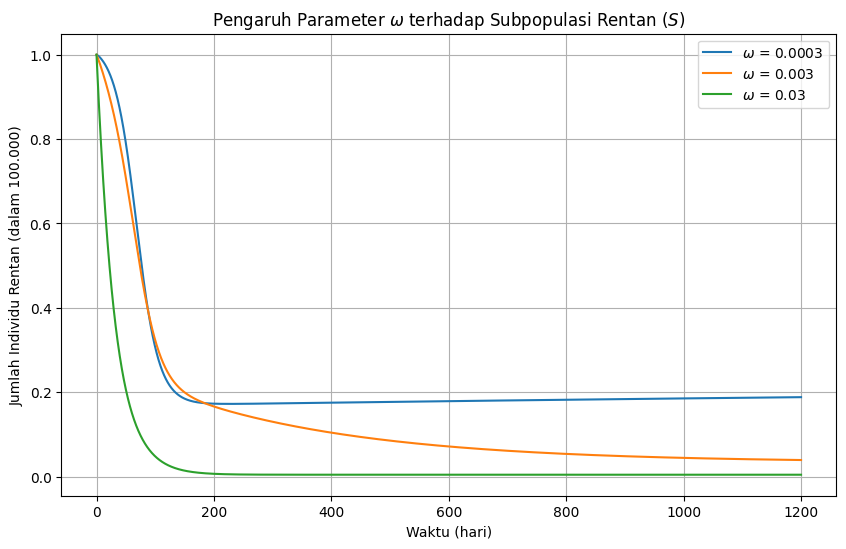

--- Nilai Akhir Subpopulasi Rentan (S) ---
Final S(t) at t = 1200.0 for omega = 0.0003: 0.1883
Final S(t) at t = 1200.0 for omega = 0.003: 0.0393
Final S(t) at t = 1200.0 for omega = 0.03: 0.0045


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, omega):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    alpha   = 0.3
    beta    = 0.100
    rho_e   = 0.020
    rho_d   = 0.050
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 1200, n)

# Variasi nilai parameter vaksinasi (omega) untuk eksplorasi
omega_values = [0.0003, 0.003, 0.03]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

# Iterasi untuk setiap nilai omega
for omega in omega_values:
    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(omega,))
    S = z[:, 0]  # Mengambil indeks 0 untuk S

    # Plot hasil simulasi untuk setiap omega
    plt.plot(t, S, label=fr'$\omega$ = {omega}')

# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Rentan (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Pengaruh Parameter $\omega$ terhadap Subpopulasi Rentan ($S$)')
plt.grid()

# Menyimpan dan menampilkan grafik
plt.savefig('pengaruh_omega_terhadap_rentan.png', dpi=300)
plt.show()

# Menampilkan nilai akhir
print("--- Nilai Akhir Subpopulasi Rentan (S) ---")
for omega in omega_values:
    z = odeint(model, z0, t, args=(omega,))
    print(f"Final S(t) at t = {t[-1]} for omega = {omega}: {np.around(z[-1, 0], 4)}")

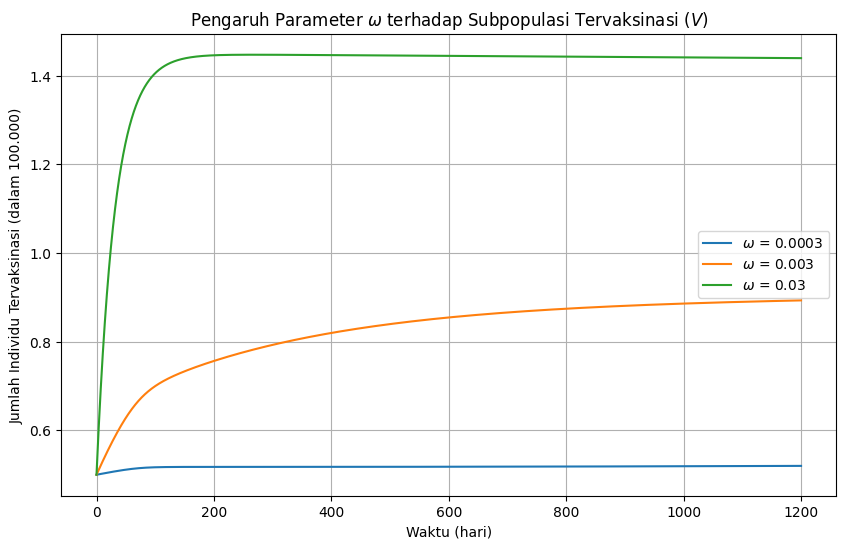

--- Nilai Akhir Subpopulasi Tervaksinasi (V) ---
Final V(t) at t = 1200.0 for omega = 0.0003: 0.5199
Final V(t) at t = 1200.0 for omega = 0.003: 0.8931
Final V(t) at t = 1200.0 for omega = 0.03: 1.4394


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, omega):
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    alpha   = 0.3
    beta    = 0.100
    rho_e   = 0.020
    rho_d   = 0.050
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 1200, n)

# Variasi nilai parameter vaksinasi (omega) untuk eksplorasi
omega_values = [0.0003, 0.003, 0.03]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

# Iterasi untuk setiap nilai omega
for omega in omega_values:
    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(omega,))
    V = z[:, 1]

    # P Plot hasil simulasi untuk setiap omega
    plt.plot(t, V, label=fr'$\omega$ = {omega}')

# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Tervaksinasi (dalam 100.000)')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Pengaruh Parameter $\omega$ terhadap Subpopulasi Tervaksinasi ($V$)')
plt.grid()

# Menyimpan dan menampilkan grafik
plt.savefig('pengaruh_omega_terhadap_vaksin.png', dpi=300)
plt.show()

# Menampilkan nilai akhir
print("--- Nilai Akhir Subpopulasi Tervaksinasi (V) ---")
for omega in omega_values:
    z = odeint(model, z0, t, args=(omega,))
    print(f"Final V(t) at t = {t[-1]} for omega = {omega}: {np.around(z[-1, 1], 4)}")

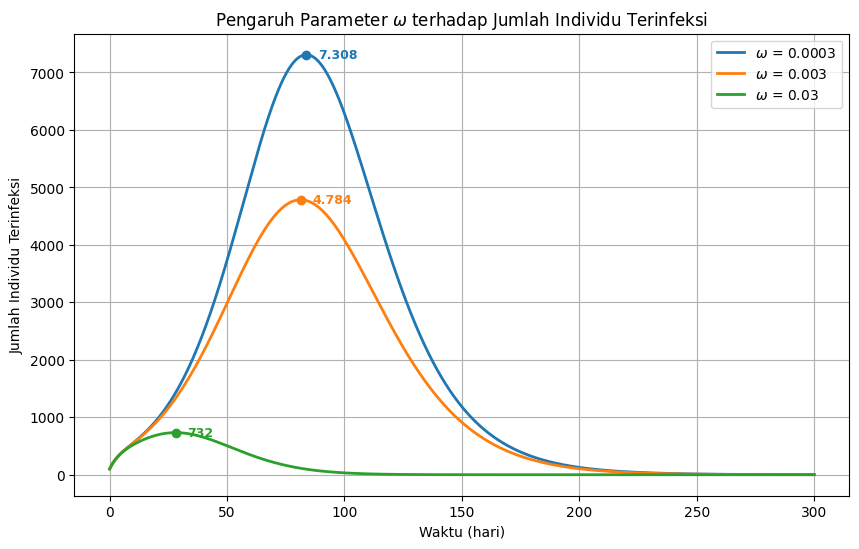

Final values at t = 300.0 for omega = 0.0003:
I(t) = 0.0
Final values at t = 300.0 for omega = 0.003:
I(t) = 0.0
Final values at t = 300.0 for omega = 0.03:
I(t) = 0.0

=== DATA PUNCAK WABAH (PEAK INFECTION) ===
Untuk omega = 0.0003, Puncaknya adalah: 0.0731 (Sekitar 7309 orang)
Untuk omega = 0.003, Puncaknya adalah: 0.0478 (Sekitar 4784 orang)
Untuk omega = 0.03, Puncaknya adalah: 0.0073 (Sekitar 733 orang)


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, omega):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    alpha   = 0.3
    beta    = 0.100
    rho_e   = 0.020
    rho_d   = 0.050
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 300, n)

# Variasi nilai parameter vaksinasi (omega) untuk eksplorasi
omega_values = [0.0003, 0.003, 0.03]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Iterasi untuk setiap nilai omega
for omega, col in zip (omega_values,colors):
    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(omega,))
    I = z[:, 3]

     # Konversi ke jiwa (1 unit = 100.000 orang)
    I_real = I * 100000

    # Plot Garis
    line, = plt.plot(t, I_real, label=fr'$\omega$ = {omega}', linewidth=2, color=col)
    warna = col

    # Cari Titik Puncak
    idx_max = np.argmax(I_real)      # Indeks data tertinggi
    t_peak = t[idx_max]              # Waktu puncak
    y_peak = I_real[idx_max]         # Jumlah orang puncak

    # Gambar Titik Bulat di Puncak
    plt.plot(t_peak, y_peak, 'o', color=warna)

    label = f"{int(y_peak):,}".replace(',', '.')
    # Beri Label Angka di Samping Titik
    plt.text(t_peak + 5, y_peak, f"{label}",
             color=warna, fontweight='bold', fontsize=9, va='center')

# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Terinfeksi')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Pengaruh Parameter $\omega$ terhadap Jumlah Individu Terinfeksi')
plt.grid()

# Menyimpan dan menampilkan grafik
plt.savefig('pengaruh_omega_terhadap_infeksi.png', dpi=300)
plt.show()

# Menampilkan nilai akhir
for omega in omega_values:
    z = odeint(model, z0, t, args=(omega,))
    print(f"Final values at t = {t[-1]} for omega = {omega}:")
    print(f"I(t) = {np.around(z[-1, 3], 4)}")

print("\n=== DATA PUNCAK WABAH (PEAK INFECTION) ===")
for omega in omega_values:
    # Jalankan simulasi untuk variasi nilai omega
    z = odeint(model, z0, t, args=(omega,))

    # Ambil data Infeksi (Kolom ke-3)
    I_data = z[:, 3]

    # Cari nilai tertinggi dalam data tersebut
    puncak_tertinggi = max(I_data)

    # Tampilkan hasilnya
    jumlah_orang = puncak_tertinggi * 100000
    print(f"Untuk omega = {omega}, Puncaknya adalah: {puncak_tertinggi:.4f} (Sekitar {jumlah_orang:.0f} orang)")


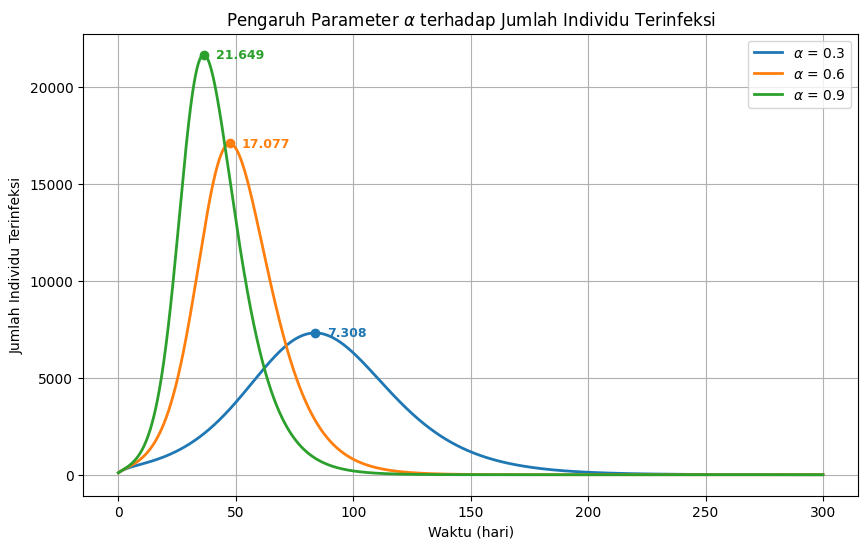

Final values at t = 300.0 for alpha = 0.3:
I(t) = 0.0
Final values at t = 300.0 for alpha = 0.6:
I(t) = 0.0
Final values at t = 300.0 for alpha = 0.9:
I(t) = -0.0

=== DATA PUNCAK WABAH (PEAK INFECTION) ===
Untuk alpha = 0.3, Puncaknya adalah: 0.0731 (Sekitar 7309 orang)
Untuk alpha = 0.6, Puncaknya adalah: 0.1708 (Sekitar 17078 orang)
Untuk alpha = 0.9, Puncaknya adalah: 0.2165 (Sekitar 21650 orang)


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, alpha):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    beta    = 0.100
    rho_e   = 0.020
    rho_d   = 0.050
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 300, n)

# Variasi nilai parameter laju penularan (alpha) untuk eksplorasi
alpha_values = [0.3, 0.6, 0.9]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

# Iterasi untuk setiap nilai alpha
for alpha in alpha_values:
    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(alpha,))
    I = z[:, 3]

    # Konversi ke jiwa (1 unit = 100.000 orang)
    I_real = I * 100000

    # Plot Garis
    line, = plt.plot(t, I_real, label=fr'$\alpha$ = {alpha}', linewidth=2)
    warna = line.get_color() # Ambil warna garis otomatis

    # Cari Titik Puncak
    idx_max = np.argmax(I_real)      # Indeks data tertinggi
    t_peak = t[idx_max]              # Waktu puncak
    y_peak = I_real[idx_max]         # Jumlah orang puncak

    # Gambar Titik Bulat di Puncak
    plt.plot(t_peak, y_peak, 'o', color=warna)

    label = f"{int(y_peak):,}".replace(',', '.')
    # Beri Label Angka di Samping Titik
    plt.text(t_peak + 5, y_peak, f"{label}",
             color=warna, fontweight='bold', fontsize=9, va='center')

# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Terinfeksi')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Pengaruh Parameter $\alpha$ terhadap Jumlah Individu Terinfeksi')
plt.grid()

# Menyimpan dan menampilkan grafik
plt.savefig('pengaruh_alpha_terhadap_infeksi.png', dpi=300)
plt.show()

# Menampilkan nilai akhir
for alpha in alpha_values:
    z = odeint(model, z0, t, args=(alpha,))
    print(f"Final values at t = {t[-1]} for alpha = {alpha}:")
    print(f"I(t) = {np.around(z[-1, 3], 4)}")

print("\n=== DATA PUNCAK WABAH (PEAK INFECTION) ===")
for alpha in alpha_values:
    # Jalankan simulasi untuk variasi nilai alpha
    z = odeint(model, z0, t, args=(alpha,))

    # Ambil data Infeksi (Kolom ke-3)
    I_data = z[:, 3]

    # Cari nilai tertinggi (Max) dalam data tersebut
    puncak_tertinggi = max(I_data)

    # Tampilkan hasilnya
    jumlah_orang = puncak_tertinggi * 100000
    print(f"Untuk alpha = {alpha}, Puncaknya adalah: {puncak_tertinggi:.4f} (Sekitar {jumlah_orang:.0f} orang)")


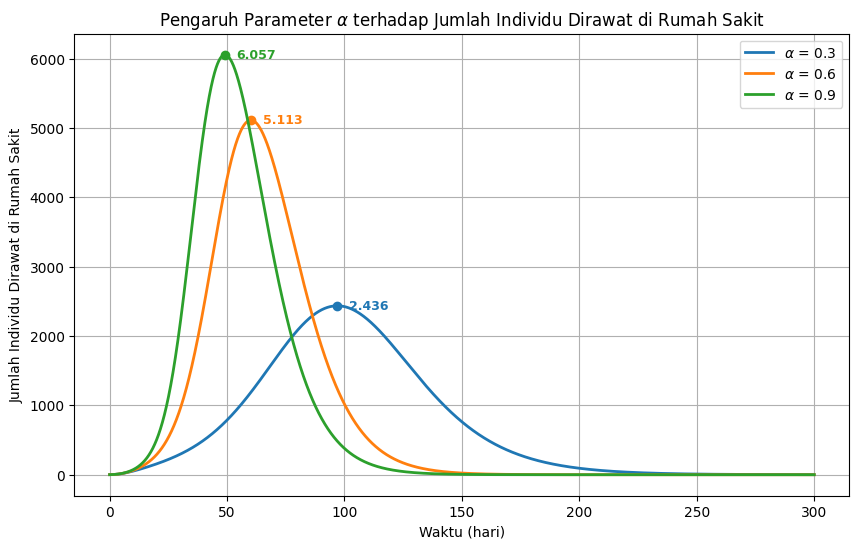

Final values at t = 300.0 for alpha = 0.3:
H(t) = 0.0
Final values at t = 300.0 for alpha = 0.6:
H(t) = 0.0
Final values at t = 300.0 for alpha = 0.9:
H(t) = -0.0

=== DATA PUNCAK DIRAWAT DI RUMAH SAKIT ===
Untuk alpha = 0.3, Puncaknya adalah: 0.0244 (Sekitar 2436 orang)
Untuk alpha = 0.6, Puncaknya adalah: 0.0511 (Sekitar 5114 orang)
Untuk alpha = 0.9, Puncaknya adalah: 0.0606 (Sekitar 6057 orang)


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, alpha):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    beta    = 0.100
    rho_e   = 0.020
    rho_d   = 0.050
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 300, n)

# Variasi nilai parameter laju penularan (alpha) untuk eksplorasi
alpha_values = [0.3, 0.6, 0.9]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

# Iterasi untuk setiap nilai alpha
for alpha in alpha_values:
    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(alpha,))
    H = z[:, 6]

    # Konversi ke jiwa (1 unit = 100.000 orang)
    H_real = H * 100000

    # Plot Garis
    line, = plt.plot(t, H_real, label=fr'$\alpha$ = {alpha}', linewidth=2)
    warna = line.get_color() # Ambil warna garis otomatis

    # Cari Titik Puncak
    idx_max = np.argmax(H_real)      # Indeks data tertinggi
    t_peak = t[idx_max]              # Waktu puncak
    y_peak = H_real[idx_max]         # Jumlah orang puncak

    # Gambar Titik Bulat di Puncak
    plt.plot(t_peak, y_peak, 'o', color=warna)

    label = f"{int(y_peak):,}".replace(',', '.')
    # Beri Label Angka di Samping Titik
    plt.text(t_peak + 5, y_peak, f"{label}",
             color=warna, fontweight='bold', fontsize=9, va='center')

# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Dirawat di Rumah Sakit')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Pengaruh Parameter $\alpha$ terhadap Jumlah Individu Dirawat di Rumah Sakit')
plt.grid()

# Menyimpan dan menampilkan grafik
plt.savefig('pengaruh_alpha_terhadap_hospitalisasi.png', dpi=300)
plt.show()

# Menampilkan nilai akhir
for alpha in alpha_values:
    z = odeint(model, z0, t, args=(alpha,))
    print(f"Final values at t = {t[-1]} for alpha = {alpha}:")
    print(f"H(t) = {np.around(z[-1, 6], 4)}")

print("\n=== DATA PUNCAK DIRAWAT DI RUMAH SAKIT ===")
for alpha in alpha_values:
    # Jalankan simulasi untuk variasi nilai alpha
    z = odeint(model, z0, t, args=(alpha,))

    # Ambil data Infeksi (Kolom ke-3)
    H_data = z[:, 6]

    # Cari nilai tertinggi (Max) dalam data tersebut
    puncak_tertinggi = max(H_data)

    # Tampilkan hasilnya
    jumlah_orang = puncak_tertinggi * 100000
    print(f"Untuk alpha = {alpha}, Puncaknya adalah: {puncak_tertinggi:.4f} (Sekitar {jumlah_orang:.0f} orang)")


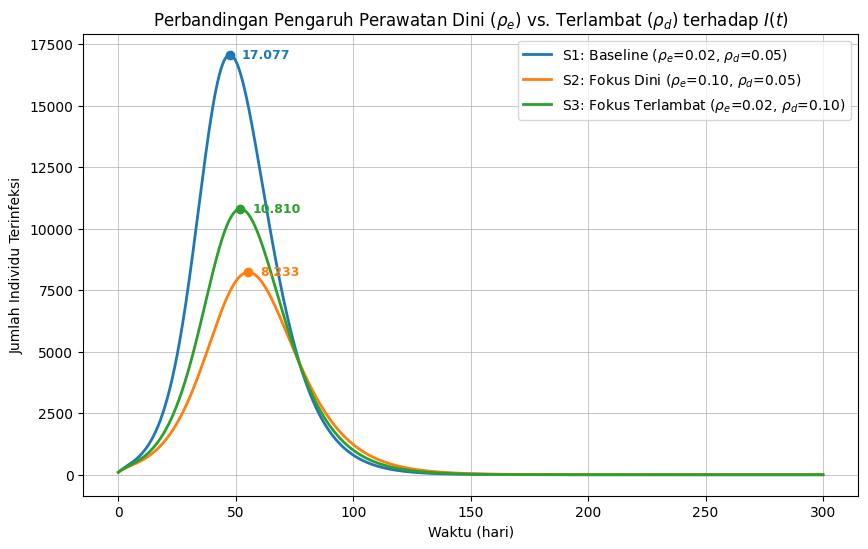


--- Puncak Infeksi Maksimum ---
Max I(t) untuk S1: Baseline (ρ_e=0.02, ρ_d=0.05) = 0.1708
Max I(t) untuk S2: Fokus Dini (ρ_e=0.10, ρ_d=0.05) = 0.0823
Max I(t) untuk S3: Fokus Terlambat (ρ_e=0.02, ρ_d=0.10) = 0.1081


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, rho_e, rho_d):
    # State variables
    S   = z[0]
    V   = z[1]
    E   = z[2]
    I   = z[3]
    T_e = z[4]
    T_d = z[5]
    H   = z[6]
    R   = z[7]

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    omega   = 0.0003
    alpha   = 0.6
    beta    = 0.100
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.150

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    dzdt = [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]
    return dzdt

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 300, n)


# DEFINISI SKENARIO PERAWATAN
scenario_values = [
    {'label': r'S1: Baseline ($\rho_e$=0.02, $\rho_d$=0.05)', 'rho_e': 0.020, 'rho_d': 0.050},
    {'label': r'S2: Fokus Dini ($\rho_e$=0.10, $\rho_d$=0.05)', 'rho_e': 0.100, 'rho_d': 0.050},
    {'label': r'S3: Fokus Terlambat ($\rho_e$=0.02, $\rho_d$=0.10)', 'rho_e': 0.020, 'rho_d': 0.100},
    ]

# Visualisasi grafik
plt.figure(figsize=(10, 6))

# Iterasi untuk setiap skenario
for scenario in scenario_values:
    rho_e = scenario['rho_e']
    rho_d = scenario['rho_d']

    # Integrasi sistem persamaan diferensial
    z = odeint(model, z0, t, args=(rho_e, rho_d))
    # Mengambil indeks 3 untuk I (Terinfeksi)
    I = z[:, 3]

    # Konversi ke jiwa (1 unit = 100.000 orang)
    I_real = I * 100000

    # Plot Garis
    line, = plt.plot(t, I_real, label=scenario['label'], linewidth=2)
    warna = line.get_color()

    # Cari Titik Puncak
    idx_max = np.argmax(I_real)      # Indeks data tertinggi
    t_peak = t[idx_max]              # Waktu puncak
    y_peak = I_real[idx_max]         # Jumlah orang puncak

    # Gambar Titik Bulat di Puncak
    plt.plot(t_peak, y_peak, 'o', color=warna)

    label = f"{int(y_peak):,}".replace(',', '.')
    # Label Angka di Samping Titik
    plt.text(t_peak + 5, y_peak, f"{label}",
             color=warna, fontweight='bold', fontsize=9, va='center')


# Pengaturan label dan judul grafik
plt.ylabel('Jumlah Individu Terinfeksi')
plt.xlabel('Waktu (hari)')
plt.legend(loc='best')
plt.title(r'Perbandingan Pengaruh Perawatan Dini ($\rho_e$) vs. Terlambat ($\rho_d$) terhadap $I(t)$')
plt.grid(True, which='both', linestyle='-', linewidth=0.5)

# Menyimpan dan menampilkan grafik
plt.savefig('perbandingan_rho_e_rho_d_terhadap_infeksi.png', dpi=300)
plt.show()

# Menampilkan nilai akhir untuk setiap skenario
print("\n--- Puncak Infeksi Maksimum ---")
for scenario in scenario_values:
    rho_e = scenario['rho_e']
    rho_d = scenario['rho_d']
    z = odeint(model, z0, t, args=(rho_e, rho_d))
    max_I = np.max(z[:, 3])

    label_bersih = scenario['label'].replace(r'\rho', 'ρ').replace('$', '').replace('{', '').replace('}', '')
    print(f"Max I(t) untuk {label_bersih} = {max_I:.4f}")


Skenario Strategi                                  | Puncak I     | Reduksi (%) 
S1: Baseline (ω dan ρ_e rendah)                    | 0.17078      | 0.00%
S2: Fokus Vaksin (ω tinggi, ρ_e rendah)            | 0.14839      | 13.11%
S3: Fokus Rawat Dini (ω rendah, ρ_e tinggi)        | 0.05194      | 69.58%
S4: Strategi Gabungan (ω dan ρ_e tinggi)           | 0.03846      | 77.48%


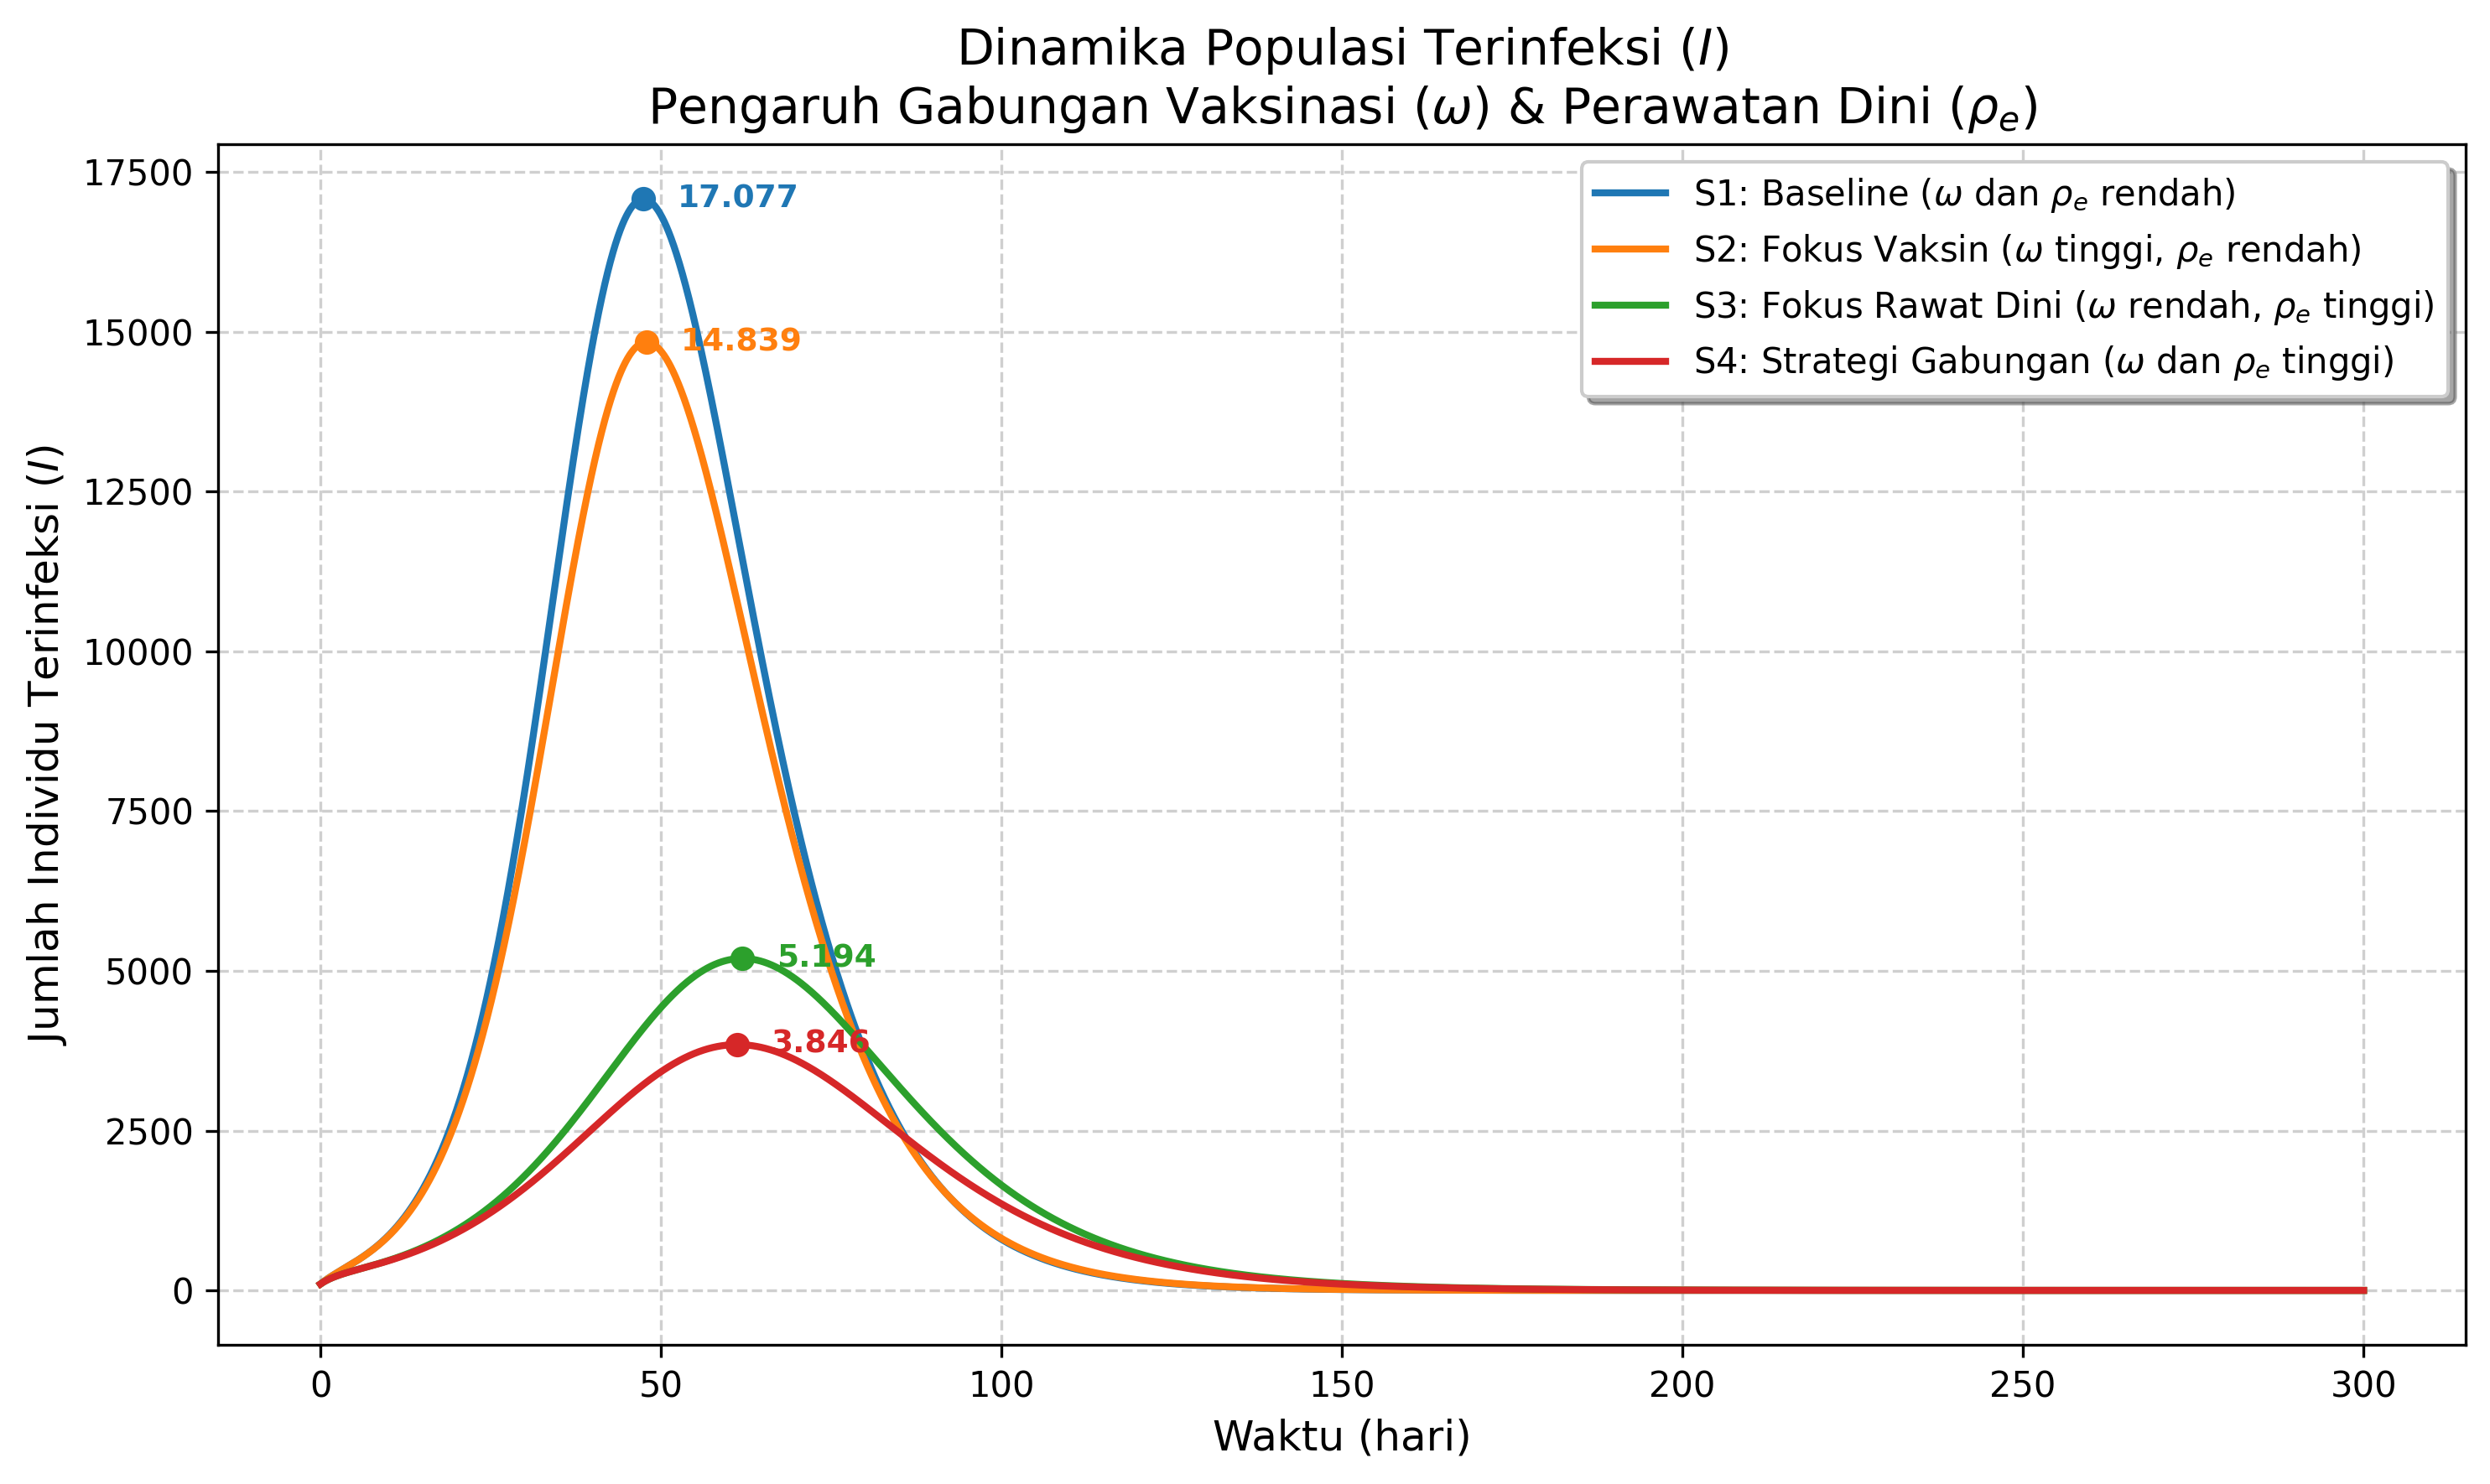

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendefinisian Fungsi Model Matematika
def model(z, t, omega, rho_e):
    S, V, E, I, T_e, T_d, H, R = z

    # Nilai parameter model
    theta   = 0.000045
    mu      = 0.000037
    delta   = 0.0003
    tau     = 0.000063
    alpha   = 0.6
    beta    = 0.1
    rho_d   = 0.05
    gamma_e = 0.142
    gamma_H = 0.142
    gamma_n = 0.071
    kappa   = 0.15

    # Sistem persamaan diferensial
    dSdt = theta - alpha*S*I + tau*V - (omega + mu)*S
    dVdt = omega*S - (mu + tau)*V
    dEdt = alpha*S*I - (mu + beta)*E
    dIdt = beta*E - (mu + delta + rho_e + rho_d + gamma_n)*I
    dT_edt = rho_e*I - (gamma_e + mu + delta)*T_e
    dT_ddt = rho_d*I - (mu + delta + kappa)*T_d
    dHdt = kappa*T_d - (gamma_H + delta + mu)*H
    dRdt = gamma_e*T_e + gamma_H*H + gamma_n*I - mu*R

    return [dSdt, dVdt, dEdt, dIdt, dT_edt, dT_ddt, dHdt, dRdt]

# Nilai awal untuk simulasi
z0 = [1, 0.5, 0.01, 0.001, 0.00005, 0.00005, 0.00001, 0.0001]

# Rentang waktu simulasi
n = 10000
t = np.linspace(0, 300, n)

# Nilai parameter strategi
omega_low  = 0.0003
omega_high = 0.003
rho_low    = 0.02
rho_high   = 0.15

scenarios = [
    {
        'label': r'S1: Baseline ($\omega$ dan $\rho_e$ rendah)',
        'omega': omega_low, 'rho_e': rho_low,
        'color': 'black', 'style': '-'
    },
    {
        'label': r'S2: Fokus Vaksin ($\omega$ tinggi, $\rho_e$ rendah)',
        'omega': omega_high, 'rho_e': rho_low,
        'color': '#1f77b4', 'style': '--'
    },
    {
        'label': r'S3: Fokus Rawat Dini ($\omega$ rendah, $\rho_e$ tinggi)',
        'omega': omega_low, 'rho_e': rho_high,
        'color': '#ff7f0e', 'style': '-.'
    },
    {
        'label': r'S4: Strategi Gabungan ($\omega$ dan $\rho_e$ tinggi)',
        'omega': omega_high, 'rho_e': rho_high,
        'color': '#2ca02c', 'style': ':'
    }
]

# Menghitung Puncak dan Reduksi
plt.figure(figsize=(10, 6), dpi=300)

print("\n" + "="*85)
print(f"{'Skenario Strategi':<50} | {'Puncak I':<12} | {'Reduksi (%)':<12}")
print("="*85)

baseline_max = 0

for i, s in enumerate(scenarios):
    z = odeint(model, z0, t, args=(s['omega'], s['rho_e']))
    I = z[:, 3]

    max_I = np.max(I)
    time_max = t[np.argmax(I)]

    if i == 0:
        baseline_max = max_I
        reduksi = 0.0
    else:
        reduksi = ((baseline_max - max_I) / baseline_max) * 100

     # Konversi ke jiwa (1 unit = 100.000 orang)
    I_real = I * 100000

    # Plot Garis
    line, = plt.plot(t, I_real, label=s['label'], linewidth=2)
    warna = line.get_color()

    # Cari Titik Puncak
    idx_max = np.argmax(I_real)      # Indeks data tertinggi
    t_peak = t[idx_max]              # Waktu puncak
    y_peak = I_real[idx_max]         # Jumlah orang puncak

    # Gambar Titik Bulat di Puncak
    plt.plot(t_peak, y_peak, 'o', color=warna)

    label = f"{int(y_peak):,}".replace(',', '.')
    # Beri Label Angka di Samping Titik
    plt.text(t_peak + 5, y_peak, f"{label}",
             color=warna, fontweight='bold', fontsize=9, va='center')

    # Membersihkan label untuk print terminal
    label_clean = s['label'].replace(r'$\omega$', 'ω').replace(r'$\rho_e$', 'ρ_e').replace('$', '')
    print(f"{label_clean:<50} | {max_I:.5f}      | {reduksi:.2f}%")

print("="*85)

# Output Grafik
plt.title(r'Dinamika Populasi Terinfeksi ($I$)' + '\n' + r'Pengaruh Gabungan Vaksinasi ($\omega$) & Perawatan Dini ($\rho_e$)', fontsize=14)
plt.xlabel('Waktu (hari)', fontsize=12)
plt.ylabel(r'Jumlah Individu Terinfeksi ($I$)', fontsize=12)
plt.legend(loc='upper right', shadow=True, fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('analisis_gabungan_omega_rho_e_fixed.png', dpi=300)
plt.show()